# Imaging Performance Comparison (Flare)
This notebook loops over different noise levels and calibration errors to generate, corrupt, image, and compare solar flare datasets.

In [1]:
import fasr_solar_simul as fss
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from scipy.special import j1
from scipy.constants import c
import os
import glob
from casatasks import tclean, applycal, clearcal
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from astropy.time import Time
from sunpy import coordinates

# Speed of light in m/s
C_LIGHT = c
import matplotlib
%matplotlib inline

In [2]:
from importlib import reload

reload(fss)
target = 'flare'
figsubfolder = 'figs/'
model_dir = r'../fasr_sim/skymodels/eruptive_flare'

In [3]:
## Memo figure sync helpers
from importlib import reload
reload(fss)
import os
import glob
import subprocess

MEMO_FIGDIR = '/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs'
os.makedirs(MEMO_FIGDIR, exist_ok=True)


def rsync_figs_to_memo(*paths, patterns=None, renamed=None, source_figdir=None, verbose=True):
    """Rsync selected figure files into the memo tex figs folder.

    Parameters
    ----------
    *paths : str
        Explicit figure paths to sync using their existing basenames.
    patterns : list[str] | tuple[str] | None
        Glob patterns resolved relative to ``source_figdir``.
    renamed : dict[str, str] | None
        Mapping of source path to destination basename inside ``MEMO_FIGDIR``.
    source_figdir : str | None
        Source directory for ``patterns``. Defaults to ``os.path.join(project, figsubfolder)``.
    verbose : bool
        Print rsync command and summary when True.
    """
    if source_figdir is None:
        source_figdir = os.path.join(project, figsubfolder)

    files_to_sync = []
    for path in paths:
        if path and os.path.exists(path):
            files_to_sync.append(path)
        elif path:
            print(f'Missing figure: {path}')

    if patterns is not None:
        for pattern in patterns:
            files_to_sync.extend(sorted(glob.glob(os.path.join(source_figdir, pattern))))

    files_to_sync = list(dict.fromkeys(files_to_sync))
    renamed = dict(renamed or {})

    if not files_to_sync and not renamed:
        raise RuntimeError(f'No matching figures found for memo sync from {source_figdir}')

    synced = 0
    if files_to_sync:
        cmd = ['rsync', '-av'] + files_to_sync + [MEMO_FIGDIR + '/']
        if verbose:
            print('Running:', ' '.join(cmd))
        subprocess.run(cmd, check=True)
        synced += len(files_to_sync)

    for src, dest_name in renamed.items():
        if not src or not os.path.exists(src):
            print(f'Missing figure: {src}')
            continue
        dest_path = os.path.join(MEMO_FIGDIR, dest_name)
        cmd = ['rsync', '-av', src, dest_path]
        if verbose:
            print('Running:', ' '.join(cmd))
        subprocess.run(cmd, check=True)
        synced += 1

    if synced == 0:
        raise RuntimeError(f'No figures were synced to {MEMO_FIGDIR}')
    if verbose:
        print(f'Synced {synced} figure(s) to {MEMO_FIGDIR}')


# Imaging Performance Comparison
looping over different noise levels and calibration errors to generate, corrupt, image, and compare

## Set up the simulation

In [4]:
# List of flare-test frequencies and imaging grids
freq_list = ['01.25GHz', '02.23GHz', '05.15GHz', '10.35GHz', '17.83GHz']
# imaging grid (try smaller cell for super-resolution experiments)
imsize = 800
cell = '0.5arcsec'
image_rms_corner_size = 100 ## in pixels (n by n) near the corner. This only applies to tclean images, not the model image.
vmax = 100.
# imsize = 2560
# cell = '1.0arcsec'
scales = [0, 6, 20]

imsizes = [800, 800, 800, 800, 1600]
cells = ['0.5arcsec', '0.5arcsec', '0.5arcsec', '0.5arcsec', '0.25arcsec']
# scales = [[0, 20, 60], 
#           [0, 10, 30], 
#           [0, 6, 20], 
#           [0, 10, 30], 
#           [0, 2, 5, 10]]
scales = [[0, 6, 15, 30], 
          [0, 4, 10, 20], 
          [0, 6, 20], 
          [0, 4, 10, 20], 
          [0, 2, 5, 10]]

# Config-dependent multiscale tuning is only needed at the two lowest frequencies,
# where the synthesized beam differs strongly between Hybrid 120 and Hybrid 120+10 remote.
scales_by_cfg = {
    '01.25GHz': {
        'fasr-a_random_spiral_hybrid_120.cfg': [0, 8, 20, 40],
        'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg': [0, 4, 10, 20],
    },
    '02.23GHz': {
        'fasr-a_random_spiral_hybrid_120.cfg': [0, 6, 15, 30],
        'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg': [0, 4, 10, 20],
    },
}

# List of configurations
project = 'FASR'
#config_files = ['fasr_Log_Spiral-168.cfg', 'fasr-a_random_spiral_hybrid_120.cfg']
config_files = ['fasr-a_random_spiral_hybrid_120.cfg']

## Antenna temperature noise levels
tsys_all = [300.]

## Define the fractional gain errors tuples: (phase and amplitude)
# 6 degrees (or 1.7% of phase error is equivalent to 10% of amplitude error )
cal_errors = [(0.1, 0.1)]

# Define channel width and integration time
channel_width_mhz = 24. # channel width in MHz
integration_time = 1. # Time per integration in seconds
duration = 1. # Total imaging duration in seconds

# Reference timestamp for the observation series
reftime_obj = fss.get_local_noon_utc(config_files[0], datetime(2017, 9, 10, 15, 45, 0))
reftime = reftime_obj.strftime('%Y-%m-%dT%H:%M:%S')  # flare simulation reference time
solar_radius_asec = coordinates.sun.angular_radius(reftime).value

# Flags to control overwriting existing data products
overwrite_ms   = False  # Overwrite measurement set?
overwrite_im   = False  # Overwrite image products?
overwrite_plot = True  # Overwrite existing plots?

weighting = 'uniform'
# Deconvolution algorithm choice
deconvolver = 'hogbom'
niter = 10000

deconvolver = 'multiscale'
niter = 10000
 
# Global plotting crop control used by all comparison plots
plot_crop_fraction = ((0.15, 0.9),(0.25, 0.75))


# Centralized tclean phase center used by all imaging calls
## this phacenter is read from full disk image. 
## The ms may has some issue that hf.calc_phasecenter_from_solxy returns a phase center that is a few arcminutes off.
phasecenter_tclean = 'J2000 11h14m17s +4d44m48s' 
# phasecenter_tclean = ''


'get_local_noon_utc' completed at 2026-03-11 14:51:00; runtime: 2.40 seconds


In [5]:
scales

[[0, 6, 15, 30], [0, 4, 10, 20], [0, 6, 20], [0, 4, 10, 20], [0, 2, 5, 10]]

## Imaging Test: Hybrid 120 vs +10 Remote Antennas (2-10 km)
This section runs a small imaging test and compares:
- Base: `fasr-a_random_spiral_hybrid_120.cfg`
- Remote: `fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg`

It uses the same sky model and imaging parameters for both, so differences are driven by UV-coverage / weighting.


Saved FASR/figs/fig_uv_density_2cfg_5freq.png


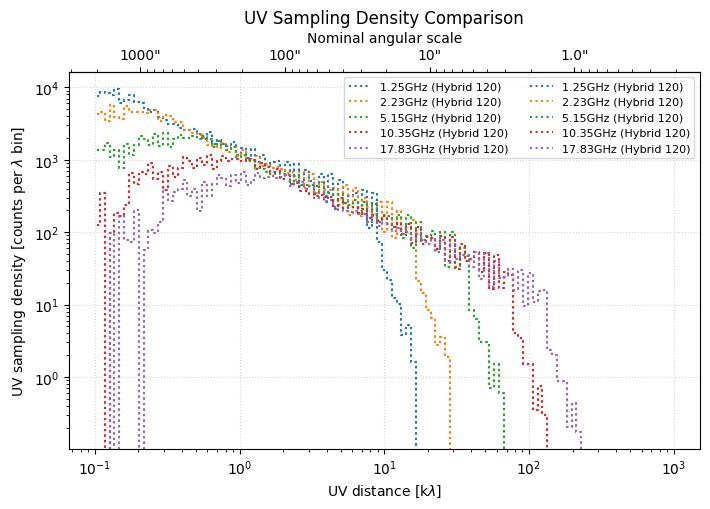

In [6]:
## UV sampling density vs UV distance [lambda] for all five flare frequencies
from importlib import reload
reload(fss)
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from matplotlib.ticker import FuncFormatter

uv_figdir = os.path.join(project, figsubfolder)
os.makedirs(uv_figdir, exist_ok=True)

cfgs_for_uv_density = globals().get('configs', [globals().get('base_cfg', config_files[0]), globals().get('remote_cfg', config_files[0])])
tsys_for_uv_density = globals().get('tsys', tsys_all[0])
nbins_uv_lambda = 120
uv_bins_klambda = np.logspace(-1, 3, nbins_uv_lambda)
line_styles_by_cfg = {
    fss.simple_array_config_label(cfgs_for_uv_density[0]): '-',
    fss.simple_array_config_label(cfgs_for_uv_density[1]): ':',
}


def klambda_to_arcsec(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = 206.265 / x[mask]
    return out


def arcsec_to_klambda(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = 206.265 / x[mask]
    return out


def fmt_arcsec(val, pos=None):
    if not np.isfinite(val) or val <= 0:
        return ''
    if val < 0.1:
        return f'{val:.2f}"'
    if val < 10:
        return f'{val:.1f}"'
    return f'{val:.0f}"'


fig, ax = plt.subplots(figsize=(7.2, 5.2))
color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
freq_colors = {freq: color_cycle[i % len(color_cycle)] for i, freq in enumerate(freq_list)}

for cfg_for_uv_density in cfgs_for_uv_density:
    cfg_label = fss.simple_array_config_label(cfg_for_uv_density)
    line_style = line_styles_by_cfg.get(cfg_label, '-')
    if cfg_label != 'Hybrid 120':
        cfg_label = cfg_label.replace('Hybrid 120 ', '')

    for freqstr in freq_list:
        msname = fss.make_msname(
            project, target, freqstr, Time(reftime).datetime,
            duration, integration_time, cfg_for_uv_density, tsys_for_uv_density
        )
        msfile = msname + '.ms'
        if not os.path.exists(msfile):
            print(f'Skipping missing MS: {msfile}')
            continue

        uvd_m = fss.uv_distance_m_from_ms(msfile)
        freq_hz = fss.freqstr_to_hz(freqstr)
        wavelength_m = 3e8 / freq_hz
        uvd_lambda = uvd_m / wavelength_m
        uvd_klambda = uvd_lambda / 1000.0

        counts, edges = np.histogram(uvd_klambda, bins=uv_bins_klambda)
        centers = 0.5 * (edges[:-1] + edges[1:])
        width = np.diff(edges)
        density = counts / width
        ax.step(
            centers, density, where='mid', lw=1.5,
            color=freq_colors[freqstr], linestyle=line_style,
            label=f'{freqstr.lstrip("0")} ({cfg_label})'
        )

ax.set_xlabel(r'UV distance [k$\lambda$]')
ax.set_ylabel(r'UV sampling density [counts per $\lambda$ bin]')
ax.set_title('UV Sampling Density Comparison')
ax.grid(True, alpha=0.5, linestyle=':')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)

secax = ax.secondary_xaxis('top', functions=(klambda_to_arcsec, arcsec_to_klambda))
secax.set_xlabel('Nominal angular scale')
secax.xaxis.set_major_formatter(FuncFormatter(fmt_arcsec))

plt.tight_layout()
uv_figname = os.path.join(uv_figdir, 'fig_uv_density_2cfg_5freq.png')
fig.savefig(uv_figname, dpi=200, bbox_inches='tight')
print(f'Saved {uv_figname}')
plt.show()


In [7]:
## Rsync the UV-density figure to the memo tex figs folder
uv_sync_source = uv_figname if os.path.exists(uv_figname) else os.path.join(project, figsubfolder, 'fig_uv_sampling_density_compare_2cfg_5freq.png')
rsync_figs_to_memo(renamed={uv_sync_source: 'fig_uv_density_2cfg_5freq.png'})


Running: rsync -av FASR/figs/fig_uv_density_2cfg_5freq.png /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_uv_density_2cfg_5freq.png
sending incremental file list
fig_uv_density_2cfg_5freq.png

sent 156,759 bytes  received 35 bytes  313,588.00 bytes/sec
total size is 156,601  speedup is 1.00
Synced 1 figure(s) to /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs


Processing flare imaging test at 01.25GHz
Total flux within primary beam used to calcuate the antenna temperature: 80.9 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 01.25GHz): 311K
80.8642
Calculate antenna temperature from total flux 80.8642 sfu incident on the dish
Total noise temperature (K): 6.105e+02 K
Estimated SEFD: 1.709e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.064e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 5.741e+00 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.466e+02 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 80.9 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 01.25GHz): 311K
80.8642
Calculate antenna temperature from total flux 80.8642 sfu incident on the dish
Total noise temperature (K): 6.105e+02 K
Estimated SEFD: 1.709e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 1.905e+00 Jy/

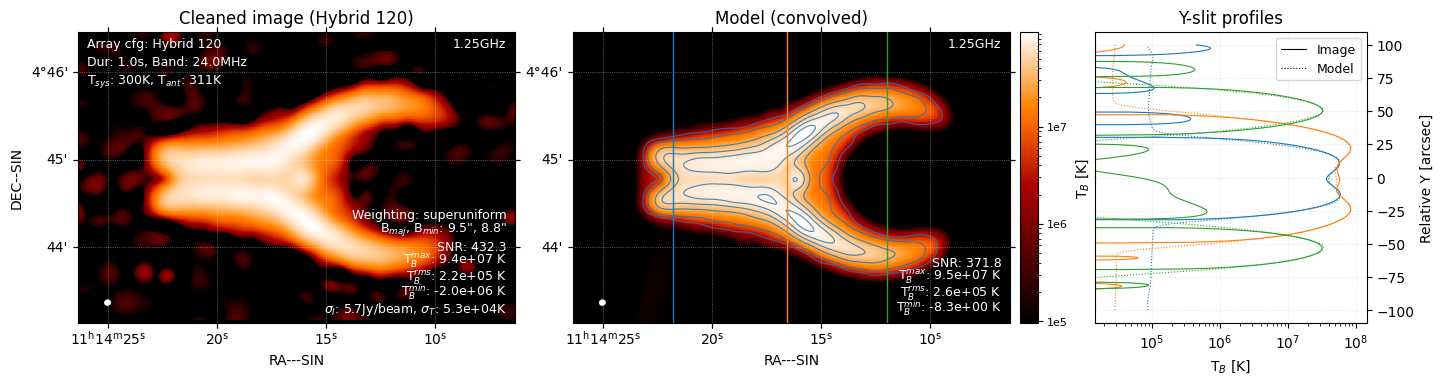

Saved figure: FASR/figs/fig_h120_0125_compare.jpg
Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.476e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 4.224e+05 K
Peak of sep10_flare_cs_model.01.25GHz.I.im: 1.145e+08 K
rms of sep10_flare_cs_model.01.25

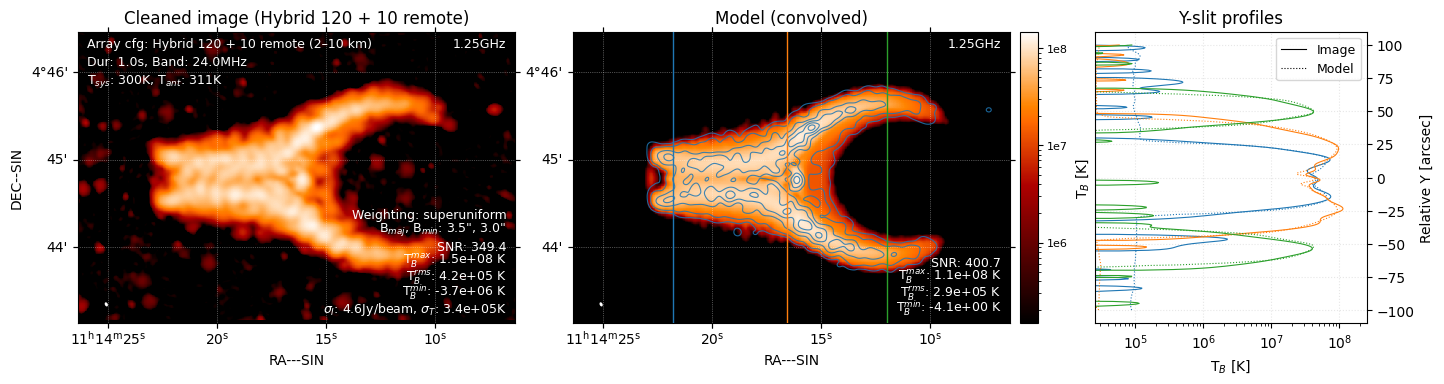

Saved figure: FASR/figs/fig_remote10_0125_compare.jpg
Processing flare imaging test at 02.23GHz
Total flux within primary beam used to calcuate the antenna temperature: 654.2 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 02.23GHz): 2512K
654.1891
Calculate antenna temperature from total flux 654.1891 sfu incident on the dish
Total noise temperature (K): 2.812e+03 K
Estimated SEFD: 7.871e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 9.507e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 2.114e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 1.136e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 654.2 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 02.23GHz): 2512K
654.1891
Calculate antenna temperature from total flux 654.1891 sfu incident on the dish
Total noise temperature (K): 2.812e+03 K
Estimated SEFD: 7.871e+06 Jy
Estimated natu

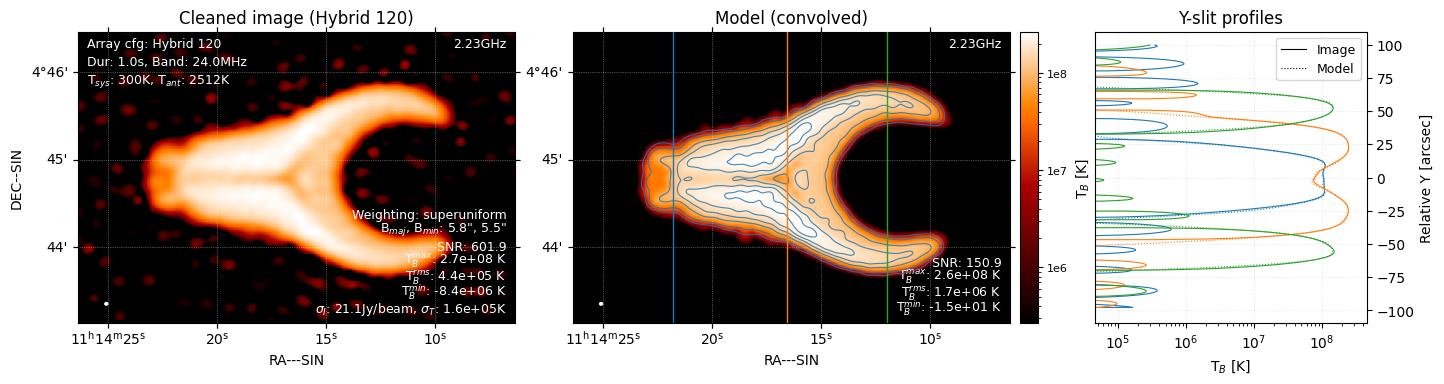

Saved figure: FASR/figs/fig_h120_0223_compare.jpg
Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 3.021e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 1.015e+06 K
Peak of sep10_flare_cs_model.02.23GHz.I.im: 2.923e+08 K
rms of sep10_flare_cs_model.02.23

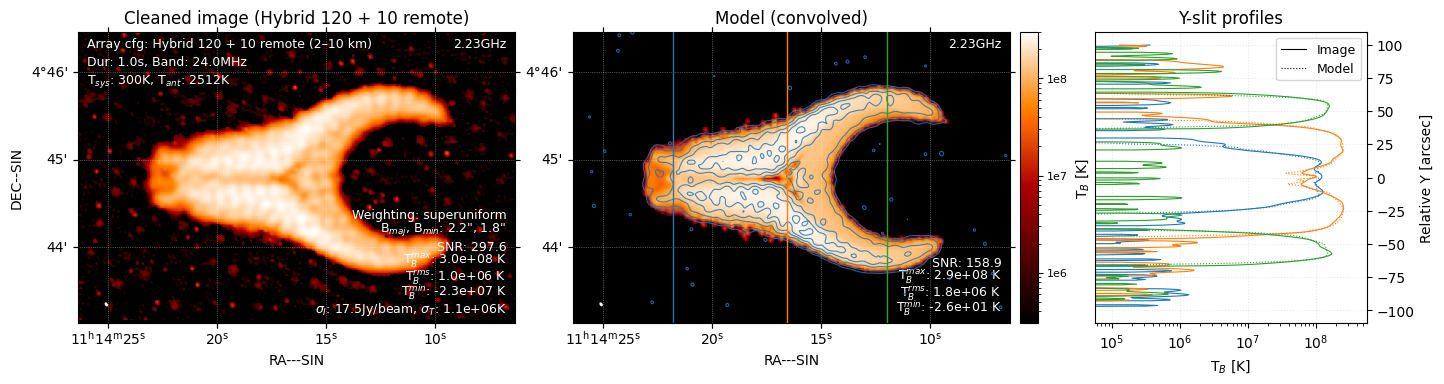

Saved figure: FASR/figs/fig_remote10_0223_compare.jpg
Processing flare imaging test at 05.15GHz
Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 05.15GHz): 6377K
1660.84
Calculate antenna temperature from total flux 1660.84 sfu incident on the dish
Total noise temperature (K): 6.677e+03 K
Estimated SEFD: 1.869e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.257e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.823e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.698e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 05.15GHz): 6377K
1660.84
Calculate antenna temperature from total flux 1660.84 sfu incident on the dish
Total noise temperature (K): 6.677e+03 K
Estimated SEFD: 1.869e+07 Jy
Estimated natura

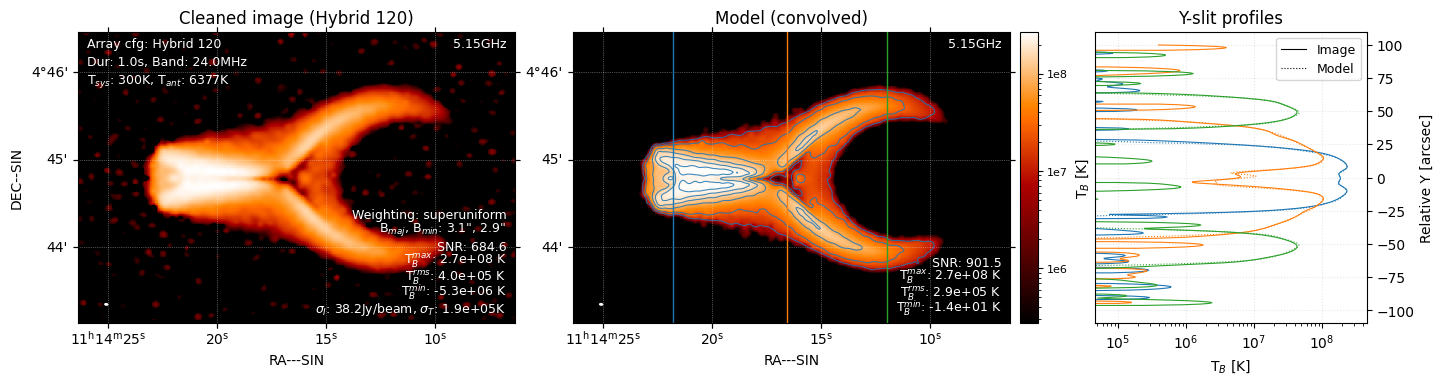

Saved figure: FASR/figs/fig_h120_0515_compare.jpg


2026-03-11 19:27:20	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.947388 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 2.880e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 1.053e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.527e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.921e+05 K
Plotting both pan

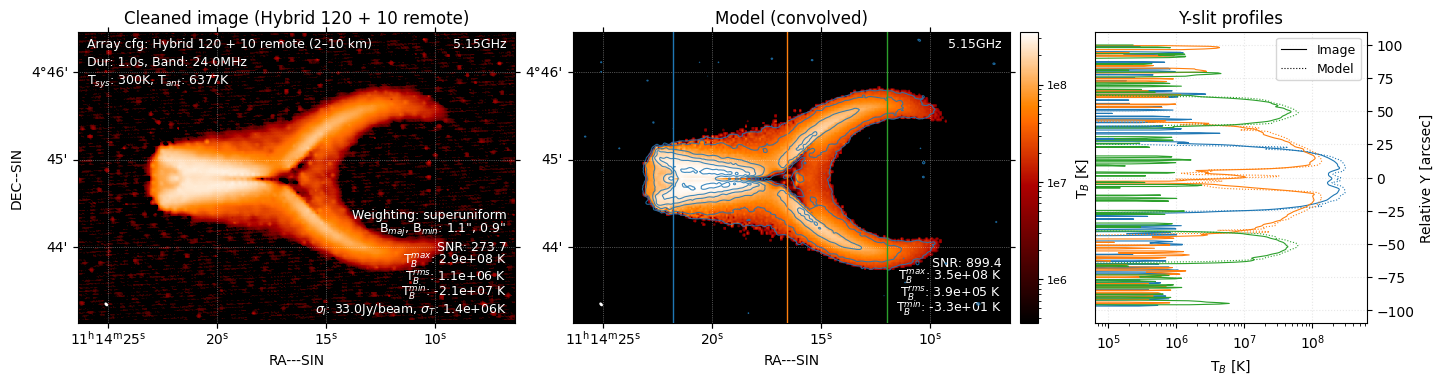

Saved figure: FASR/figs/fig_remote10_0515_compare.jpg
Processing flare imaging test at 10.35GHz
Total flux within primary beam used to calcuate the antenna temperature: 1626.6 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 10.35GHz): 6246K
1626.5923
Calculate antenna temperature from total flux 1626.5923 sfu incident on the dish
Total noise temperature (K): 6.546e+03 K
Estimated SEFD: 1.832e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.213e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.054e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.645e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 1626.6 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 10.35GHz): 6246K
1626.5923
Calculate antenna temperature from total flux 1626.5923 sfu incident on the dish
Total noise temperature (K): 6.546e+03 K
Estimated SEFD: 1.832e+07 Jy
Estimate

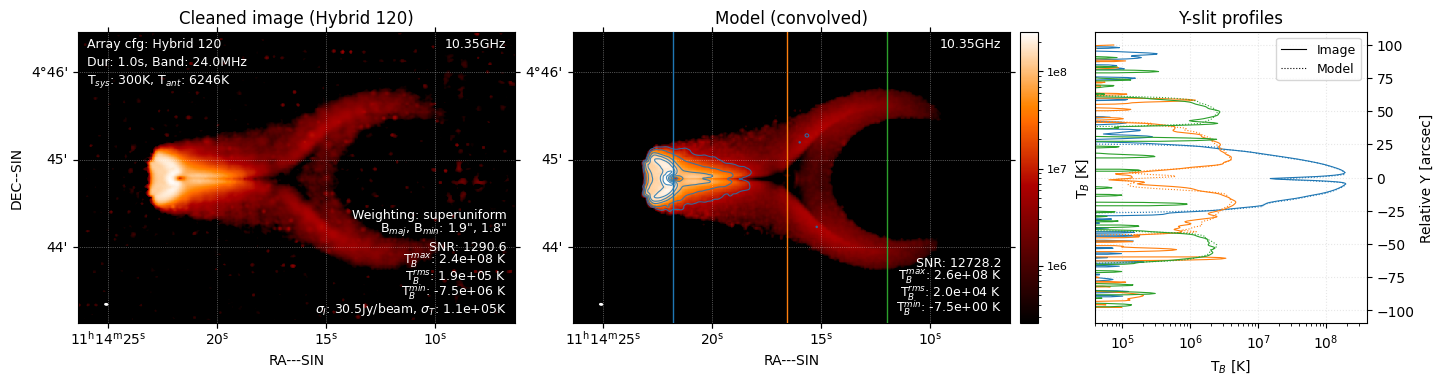

Saved figure: FASR/figs/fig_h120_1035_compare.jpg


2026-03-11 19:28:00	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.27231 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 2.477e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 2.528e+05 K
Peak of sep10_flare_cs_model.10.35GHz.I.im: 2.702e+08 K
rms of sep10_flare_cs_model.10.35GHz.I.im (off-disk): 2.122e+04 K
Plotting both pan

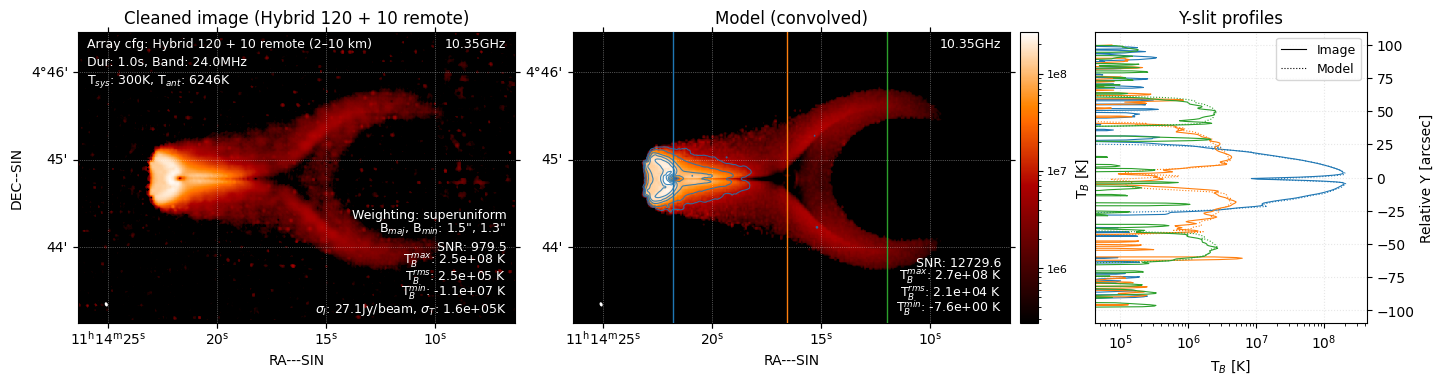

Saved figure: FASR/figs/fig_remote10_1035_compare.jpg
Processing flare imaging test at 17.83GHz
Total flux within primary beam used to calcuate the antenna temperature: 2141.7 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 17.83GHz): 8224K
2141.667
Calculate antenna temperature from total flux 2141.667 sfu incident on the dish
Total noise temperature (K): 8.524e+03 K
Estimated SEFD: 2.386e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.882e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.511e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 3.444e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 2141.7 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 17.83GHz): 8224K
2141.667
Calculate antenna temperature from total flux 2141.667 sfu incident on the dish
Total noise temperature (K): 8.524e+03 K
Estimated SEFD: 2.386e+07 Jy
Estimated na

2026-03-11 19:28:18	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.19161 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.863e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 5.598e+04 K
Peak of sep10_flare_cs_model.17.83GHz.I.im: 2.401e+08 K
rms of sep10_flare_cs_model.17.83GHz.I.im (off-disk): 2.821e+03 K
Plotting both panels with shared vmin=2.393e+05 K, 

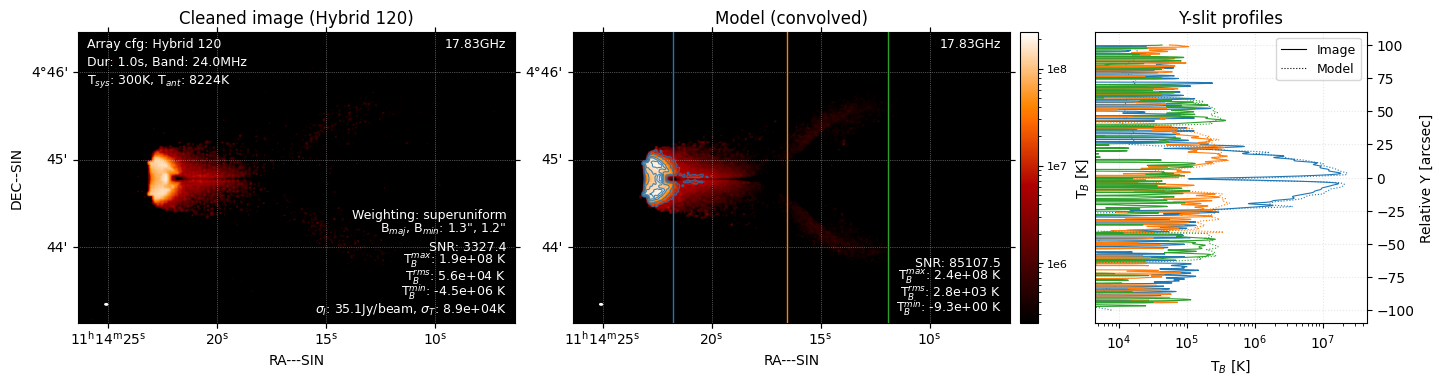

Saved figure: FASR/figs/fig_h120_1783_compare.jpg


2026-03-11 19:28:38	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.90197 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.943e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 8.319e+04 K
Peak of sep10_flare_cs_model.17.83GHz.I.im: 3.399e+08 K
rms of sep10_flare_cs_model.17.83GHz.I.im (off-disk): 3.973e+03 K
Plotting both pan

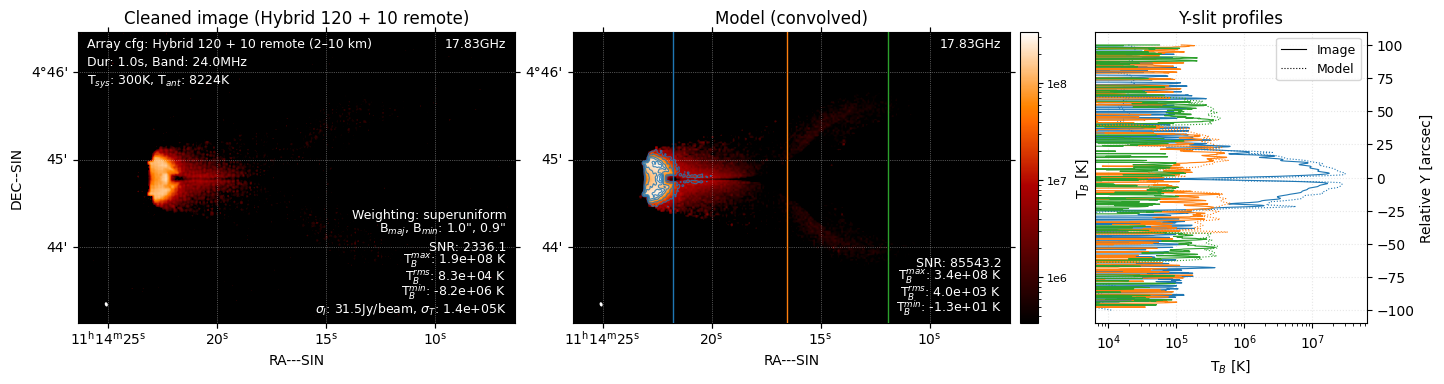

Saved figure: FASR/figs/fig_remote10_1783_compare.jpg


In [20]:
phasecenter_tclean = globals().get('phasecenter_tclean', 'J2000 11h14m13.36s +30d04m44s')
reload(fss)
import os
import sys
_suncasa_src = os.path.expanduser('~/Dropbox/PycharmProjects/suncasa/suncasa-src')
if _suncasa_src not in sys.path:
    sys.path.append(_suncasa_src)
from suncasa.utils import helioimage2fits as hf
reload(hf)

# --- Configs to compare ---
base_cfg = 'fasr-a_random_spiral_hybrid_120.cfg'
remote_cfg = 'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg'

# noise / integration
tsys = 300.
channel_width_mhz = 24.
integration_time = 1.
duration = 1.
image_rms_corner_size = 100 ## in pixels (n by n) near the corner. This only applies to tclean images, not the model image.
vmax = 100.

# flare-centered phasecenter in solar X/Y arcsec
flare_xycen = (1050, -140)

# calibration errors (quiet-Sun style default)
cal_errors = globals().get('cal_errors', [(0.1, 0.1)])
phaerr, amperr = cal_errors[0]

# baseline CASA timestamp
reftime_casa = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')

# Make sure output dirs exist
figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
caltbdir = os.path.join(project, 'caltbs')
os.makedirs(caltbdir, exist_ok=True)

configs = [base_cfg, remote_cfg]
labels = [fss.simple_array_config_label(cfg) for cfg in configs]
# weightings = ['natural', 'uniform']
weightings = ['superuniform']

## imaging correction for a systematic shift of the image center from the model center. This is needed to align the model and image for accurate residual and contour overlay, especially when the image center is not perfectly aligned with the flare center in the model. The shift is specified in arcseconds and applied as a correction to the image WCS after tclean.
image_arcsec_shift=(0.0, 1.3)


def _ensure_default_calibration(msfile, overwrite=False):
    """Apply default phase/amplitude calibration errors to a derived MS copy."""
    phaerr_deg = np.rad2deg(phaerr)
    gaintable = [
        f'caltb_FASR_corrupt_{phaerr_deg:.0f}deg.ph',
        f'caltb_FASR_corrupt_{np.int_(amperr * 100)}pct.amp',
    ]
    if not os.path.exists(gaintable[0]) or not os.path.exists(gaintable[1]):
        gaintable = fss.generate_caltb(
            msfile,
            caltype=['ph', 'amp'],
            calerr=[phaerr, amperr],
            caltbdir=caltbdir,
        )
    calibrated_ms = msfile.replace('.ms', '_defaultcal.ms')
    if overwrite and os.path.exists(calibrated_ms):
        fss.remove_path(calibrated_ms)
    if not os.path.exists(calibrated_ms):
        shutil.copytree(msfile, calibrated_ms)
    clearcal(vis=calibrated_ms)
    applycal(vis=calibrated_ms, gaintable=gaintable, applymode='calonly', calwt=False)
    return calibrated_ms


# Optional: overwrite only +10 remote images (leave Hybrid 120 images untouched)
overwrite_remote_im = False  # set True to re-run only remote_cfg tclean images

for freqstr, imsize, cell_arcsec, scales_for_freq in zip(freq_list, imsizes, cells, scales):
    print(f'Processing flare imaging test at {freqstr}')
    solar_model = f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits'
    _noise_terms_cache = {}

    def _noise_terms_for_cfg(config_file):
        key = (config_file, freqstr, imsize, cell_arcsec)
        if key in _noise_terms_cache:
            return _noise_terms_cache[key]

        antenna_params = np.genfromtxt(config_file, comments='#')
        dish_diameter = antenna_params[0, 3]
        uv_cell = 1. / (imsize * float(cell_arcsec.rstrip('arcsec')) / 206265.)
        total_flux = fss.calc_total_flux_on_dish(solar_model, dish_diameter=dish_diameter, freqghz=freqstr)
        tant = fss.total_flux_to_tant(total_flux, eta_a=0.6, dish_diameter=dish_diameter)
        print(f'Tant ({os.path.basename(config_file)}, {freqstr}): {tant:.0f}K')
        noisejy, sigma_na, sigma_un = fss.calc_noise(
            tsys, config_file, dish_diameter=dish_diameter,
            total_flux=total_flux, duration=duration,
            integration_time=integration_time,
            channel_width_mhz=channel_width_mhz,
            freqghz=freqstr, uv_cell=uv_cell,
        )
        sigma_jy = sigma_un / np.sqrt((duration / integration_time))
        terms = {
            'dish_diameter': dish_diameter,
            'uv_cell': uv_cell,
            'total_flux': total_flux,
            'tant': tant,
            'noisejy': noisejy,
            'sigma_na': sigma_na,
            'sigma_un': sigma_un,
            'sigma_jy': sigma_jy,
        }
        _noise_terms_cache[key] = terms
        return terms

    for weighting in weightings:
        ims = []
        for config_file in configs:
            noise_terms = _noise_terms_for_cfg(config_file)
            scales_this_cfg = scales_by_cfg.get(freqstr, {}).get(os.path.basename(config_file), scales_for_freq)
            msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, config_file, tsys)
            msfile = f'{msname}.ms'

            if (not os.path.exists(msfile)) or overwrite_ms:
                if os.path.exists(msfile) and overwrite_ms:
                    os.system('rm -rf ' + msfile)
                print('Start generating ms:', msfile)
                msfile = fss.generate_ms(
                    config_file, solar_model, reftime_casa, freqstr,
                    integration_time=integration_time, duration=duration,
                    channel_width_mhz=channel_width_mhz,
                    msname=msfile, tsys=tsys, usehourangle=True,
                    uv_cell=noise_terms['uv_cell']
                )

            # Make an image name that includes cfg + weighting
            imname = f'{msname}_{weighting}_{deconvolver}'
            is_remote_cfg = (config_file == remote_cfg)
            overwrite_this_image = overwrite_im or (overwrite_remote_im and is_remote_cfg)
            if os.path.exists(f'{imname}.image') and overwrite_this_image:
                for j in ['.image', '.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                    os.system(f'rm -rf {imname}{j}')

            if not os.path.exists(f'{imname}.image'):
                print('Imaging:', imname)
                calibrated_msfile = _ensure_default_calibration(msfile, overwrite=overwrite_ms)
                tclean(
                    vis=calibrated_msfile, imagename=imname,
                    datacolumn='data',
                    specmode='mfs',
                    deconvolver=deconvolver, scales=scales_this_cfg,
                    gain=0.2, cycleniter=200, minpsffraction=0.1, pblimit=0.01,
                    imsize=imsize, cell=cell_arcsec,
                    phasecenter=phasecenter_tclean,
                    weighting=weighting,
                    niter=niter,
                    interactive=False
                )
                for j in ['.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                    os.system(f'rm -rf {imname}{j}')

            ims.append(imname + '.image')

        # Compare each config against the flare model with the shared plotting utility
        model_path = os.path.join(project, 'msfiles', target, os.path.basename(solar_model.replace('.fits', '.im')))
        image_meta_common = {
            'freq': freqstr,
            'tsys': f'{tsys:.0f}K',
            'cal_error': f'{np.rad2deg(phaerr):.0f}'+r'$^{\circ}$ Pha' + f' & {np.int_(amperr * 100)}% Amp',
            'duration': f'{duration}s',
            'bandwidth': f'{channel_width_mhz}MHz',
        }
        cfg_display_names = [os.path.basename(cfg) for cfg in configs]
        # slit_locations_compare = globals().get('slit_locations_compare', (0.23, 0.49, 0.75))
        slit_locations_compare = (0.23, 0.49, 0.72)

        for idx_cfg, im_path in enumerate(ims):
            fig_compare, axs_compare = fss.plot_two_casa_images_with_convolution_sunpy(
                im_path,
                model_path,
                crop_fraction=globals().get('plot_crop_fraction', (0.0, 1.0)),
                reftime=reftime,
                figsize=(15, 3.6),
                image_meta={
                    **image_meta_common,
                    'title': [f'Cleaned image ({labels[idx_cfg]})', 'Model (convolved)'],
                    'array_config': cfg_display_names[idx_cfg],
                    'tant': f"{_noise_terms_for_cfg(configs[idx_cfg])['tant']:.0f}K",
                    'sigma_jy': f"{_noise_terms_for_cfg(configs[idx_cfg])['sigma_jy']:.1f}Jy/beam",
                    'imaging_weighting': weighting,
                },
                cmap='hinodexrt',
                vmax=vmax,
                vmin=0.1,
                conv_tag=f'.compare_{weighting}_{idx_cfg}',
                overwrite_conv=True,
                rms_mask_radius=1.2,
                image_rms_corner_size=image_rms_corner_size,
                coord_frame='radec',
                match_fov=True,
                align_model_time_to_image=True,
                north_up=False,
                apply_hpc_p_angle=False,
                anchor_model_wcs_to_image=True,
                use_reftime_for_hpc=True,
                slit_locations=slit_locations_compare,
                overlay_image_contours=True,
                image_contour_levels=(3, 10, 30, 50, 70, 90),
                image_arcsec_shift=image_arcsec_shift,
            )
            plt.show()

            freq_tag = freqstr.replace('.', '').replace('GHz', '')
            cfg_label_short = fss.simple_array_config_label(configs[idx_cfg])
            cfg_tag = 'h120' if cfg_label_short == 'Hybrid 120' else 'remote10'
            figname = os.path.join(figdir, f'fig_{cfg_tag}_{freq_tag}_compare.jpg')
            if os.path.exists(figname) and overwrite_plot:
                os.system('rm -rf ' + figname)
            if not os.path.exists(figname):
                fig_compare.savefig(figname, dpi=300, bbox_inches='tight')
                print('Saved figure:', figname)


In [26]:
## Rsync the multi-frequency imaging figures to the memo tex figs folder
imaging_sync_map = {
    next((p for p in [
        os.path.join(project, figsubfolder, 'fig_h120_0125_compare.jpg'),
        os.path.join(project, figsubfolder, 'fig-fasr_fasr-a_random_spiral_hybrid_120_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.01.25GHz.I.im.jpg'),
    ] if os.path.exists(p)), os.path.join(project, figsubfolder, 'fig_h120_0125_compare.jpg')): 'fig_h120_0125_compare.jpg',
    next((p for p in [
        os.path.join(project, figsubfolder, 'fig_h120_0223_compare.jpg'),
        os.path.join(project, figsubfolder, 'fig-fasr_fasr-a_random_spiral_hybrid_120_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.02.23GHz.I.im.jpg'),
    ] if os.path.exists(p)), os.path.join(project, figsubfolder, 'fig_h120_0223_compare.jpg')): 'fig_h120_0223_compare.jpg',
    next((p for p in [
        os.path.join(project, figsubfolder, 'fig_h120_0515_compare.jpg'),
        os.path.join(project, figsubfolder, 'fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I.im.jpg'),
    ] if os.path.exists(p)), os.path.join(project, figsubfolder, 'fig_h120_0515_compare.jpg')): 'fig_h120_0515_compare.jpg',
    next((p for p in [
        os.path.join(project, figsubfolder, 'fig_h120_1035_compare.jpg'),
        os.path.join(project, figsubfolder, 'fig-fasr_fasr-a_random_spiral_hybrid_120_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.10.35GHz.I.im.jpg'),
    ] if os.path.exists(p)), os.path.join(project, figsubfolder, 'fig_h120_1035_compare.jpg')): 'fig_h120_1035_compare.jpg',
    next((p for p in [
        os.path.join(project, figsubfolder, 'fig_h120_1783_compare.jpg'),
        os.path.join(project, figsubfolder, 'fig-fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.17.83GHz.I.im.jpg'),
    ] if os.path.exists(p)), os.path.join(project, figsubfolder, 'fig_h120_1783_compare.jpg')): 'fig_h120_1783_compare.jpg',
}
rsync_figs_to_memo(renamed=imaging_sync_map)


Running: rsync -av FASR/figs/fig_h120_0125_compare.jpg /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_h120_0125_compare.jpg
sending incremental file list
fig_h120_0125_compare.jpg

sent 423,882 bytes  received 35 bytes  847,834.00 bytes/sec
total size is 423,664  speedup is 1.00
Running: rsync -av FASR/figs/fig_h120_0223_compare.jpg /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_h120_0223_compare.jpg
sending incremental file list
fig_h120_0223_compare.jpg

sent 433,505 bytes  received 35 bytes  867,080.00 bytes/sec
total size is 433,279  speedup is 1.00
Running: rsync -av FASR/figs/fig_h120_0515_compare.jpg /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_h120_0515_compare.jpg
sending incremental file list
fig_h120_0515_co

In [14]:
reload(fss)
debug_rows = []

for freqstr in freq_list:
    msname_local = fss.make_msname(
        project, target, freqstr, Time(reftime).datetime,
        duration, integration_time, base_cfg, tsys
    )
    image_path_local = f'{msname_local}_{weightings[0]}_{deconvolver}.image'
    model_im_local = os.path.join(
        project, 'msfiles', target,
        os.path.basename(f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits'.replace('.fits', '.im'))
    )

    debug_rows.append(
        fss.debug_casa_image_model_registration_sunpy(
            image_path_local,
            model_im_local,
            crop_fraction=crop_fraction,
            reftime=reftime,
            image_meta={'freq': freqstr},
            coord_frame='hpc',
            match_fov=True,
            align_model_time_to_image=True,
            anchor_model_wcs_to_image=True,
            use_reftime_for_hpc=True,
            overwrite_conv=False,
            overwrite_fits=False,
        )
    )

for row in debug_rows:
    print(
        row['freq'],
        f"peak dx={row['peak_dx_arcsec']:.2f}\" dy={row['peak_dy_arcsec']:.2f}\"",
        f"r/beam={row['offset_over_geom_beam']:.2f}",
        f"img_peak=({row['image_peak_tx_arcsec']:.2f}\", {row['image_peak_ty_arcsec']:.2f}\")",
        f"mdl_peak=({row['model_peak_tx_arcsec']:.2f}\", {row['model_peak_ty_arcsec']:.2f}\")",
        f"crval1/2 img=({row['sub1_crval1']:.3f}, {row['sub1_crval2']:.3f})",
        f"mdl=({row['sub2_crval1']:.3f}, {row['sub2_crval2']:.3f})",
    )


Image1 map obstime: 2017-09-10T19:33:57.000, Image2 map obstime: 2017-09-10T19:33:57.000
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 9.406e+07 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 2.183e+05 K
Peak of sep10_flare_cs_model.01.25GHz.I.im: 9.494e+07 K
rms of sep10_flare_cs_model.01.25GHz.I.im (off-disk): 2.553e+05 K
Plotting both panels with shared vmin=3.762e+00 K, vmax=8.465e+07 K
'plot_two_casa_images_with_convolution_sunpy' completed at 2026-03-11 12:34:59; runtime: 0.22 seconds
Image1 map obstime: 2017-09-10T19:33:57.000, Image2 map obstime: 2017-09-10T19:33:57.000
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 2.653e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_s

In [16]:
reload(fss)
debug_rows_radec = []

for freqstr in freq_list:
    msname_local = fss.make_msname(
        project, target, freqstr, Time(reftime).datetime,
        duration, integration_time, base_cfg, tsys
    )
    image_path_local = f'{msname_local}_{weightings[0]}_{deconvolver}.image'
    model_im_local = os.path.join(
        project, 'msfiles', target,
        os.path.basename(f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits'.replace('.fits', '.im'))
    )

    debug_rows_radec.append(
        fss.debug_casa_image_model_registration_sunpy(
            image_path_local,
            model_im_local,
            crop_fraction=crop_fraction,
            reftime=reftime,
            image_meta={'freq': freqstr},
            coord_frame='radec',
            match_fov=True,
            align_model_time_to_image=True,
            anchor_model_wcs_to_image=False,
            use_reftime_for_hpc=False,
            overwrite_conv=False,
            overwrite_fits=False,
        )
    )

for row in debug_rows_radec:
    print(
        row['freq'],
        f"peak dx={row['peak_dx_arcsec']:.2f}\" dy={row['peak_dy_arcsec']:.2f}\"",
        f"r/beam={row['offset_over_geom_beam']:.2f}",
    )


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 9.406e+07 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 2.183e+05 K
Peak of sep10_flare_cs_model.01.25GHz.I.im: 9.494e+07 K
rms of sep10_flare_cs_model.01.25GHz.I.im (off-disk): 2.553e+05 K
Plotting both panels with shared vmin=3.762e+00 K, 

In [25]:
## Rsync the array-expansion figures to the memo tex figs folder
array_sync_map = {
    os.path.join(project, figsubfolder, 'fig_fasr-a_cfg_hybrid120_vs_remote10.png'): 'fig_cfg_ref_vs_remote10.png',
    next((p for p in [
        os.path.join(project, figsubfolder, 'fig_remote10_0515_compare.jpg'),
        os.path.join(project, figsubfolder, 'fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I.im.jpg'),
    ] if os.path.exists(p)), os.path.join(project, figsubfolder, 'fig_remote10_0515_compare.jpg')): 'fig_remote10_0515_compare.jpg',
}
rsync_figs_to_memo(renamed=array_sync_map)


Missing figure: FASR/figs/fig_fasr-a_cfg_hybrid120_vs_remote10.png
Running: rsync -av FASR/figs/fig_remote10_0515_compare.jpg /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_remote10_0515_compare.jpg
sending incremental file list
fig_remote10_0515_compare.jpg

sent 522,990 bytes  received 35 bytes  1,046,050.00 bytes/sec
total size is 522,745  speedup is 1.00
Synced 1 figure(s) to /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs


## This section plots the fidelity analysis for the Hybrid 120 vs +10 Remote Antennas (2-10 km) test.

Total flux within primary beam used to calcuate the antenna temperature: 80.9 sfu
80.8642
Calculate antenna temperature from total flux 80.8642 sfu incident on the dish
Total noise temperature (K): 6.105e+02 K
Estimated SEFD: 1.709e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.064e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 5.741e+00 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.466e+02 Jy for 7140 baselines
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius 

2026-03-11 20:08:50	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.19161 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.863e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 5.598e+04 K
Peak of sep10_flare_cs_model.17.83GHz.I.im: 2.401e+08 K
rms of sep10_flare_cs_model.17.83GHz.I.im (off-disk): 2.821e+03 K
Plotting both panels with shared vmin=2.393e+05 K, 

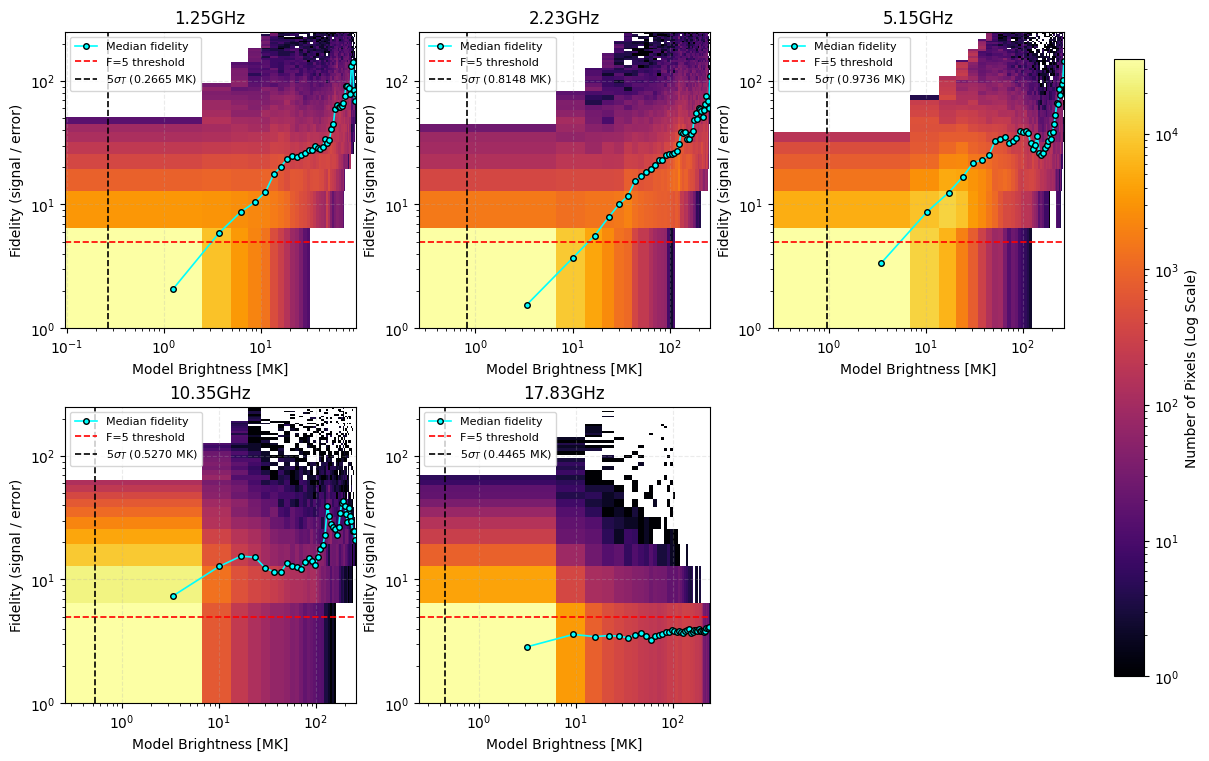

In [27]:
## Pixel-by-pixel fidelity analysis for Hybrid 120 across the five flare frequencies
from importlib import reload
reload(fss)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.time import Time

fidelity_cfg = base_cfg
fidelity_weighting = 'superuniform'
fidelity_deconvolver = 'multiscale'
fidelity_crop_fraction = globals().get('plot_crop_fraction', (0.0, 1.0))
fidelity_good_threshold = 5.0
fidelity_nbins_x = 40
fidelity_nbins_y = 40
fidelity_ymax = 250.0
fidelity_figsize = (12, 7.5)

figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=fidelity_figsize, constrained_layout=True)
axes = axes.ravel()

fidelity_figname = os.path.join(figdir, 'fig_h120_fidelity_hist.png')

for idx, freqstr_local in enumerate(freq_list):
    ax = axes[idx]
    imsize_local = imsizes[idx]
    cell_local = cells[idx]
    model_fits_local = f'{model_dir}/sep10_flare_cs_model.{freqstr_local}.I.fits'
    model_base_local = os.path.join(project, 'msfiles', target, os.path.basename(model_fits_local.replace('.fits', '.im')))
    model_path_local = fss.resolve_casa_image_path(model_base_local)
    if model_path_local is None or not os.path.exists(model_path_local):
        raise FileNotFoundError(f'Model image not found: {model_base_local}')

    msname_local = fss.make_msname(project, target, freqstr_local, Time(reftime).datetime, duration, integration_time, fidelity_cfg, tsys)
    image_path_local = f'{msname_local}_{fidelity_weighting}_{fidelity_deconvolver}.image'
    if not os.path.exists(image_path_local):
        raise FileNotFoundError(f'Cleaned image not found: {image_path_local}')

    noise_terms_local = fss.calc_noise_terms_for_cfg(
        fidelity_cfg,
        model_fits_local,
        freqstr_local,
        imsize_local,
        cell_local,
        tsys,
        duration,
        integration_time,
        channel_width_mhz,
    )

    prep = fss.plot_two_casa_images_with_convolution_sunpy(
        image_path_local,
        model_path_local,
        crop_fraction=fidelity_crop_fraction,
        reftime=reftime,
        image_meta={
            'freq': freqstr_local,
            'array_config': fss.simple_array_config_label(fidelity_cfg),
            'tsys': f'{tsys:.0f}K',
            'tant': f"{noise_terms_local['tant']:.0f}K",
            'sigma_jy': f"{noise_terms_local['sigma_jy']:.1f}Jy/beam",
            'duration': f'{duration}s',
            'bandwidth': f'{channel_width_mhz}MHz',
            'imaging_weighting': fidelity_weighting,
        },
        cmap='hinodexrt',
        vmin=0.1,
        vmax=vmax,
        conv_tag=f'.fidelity_{freqstr_local}',
        overwrite_conv=True,
        rms_mask_radius=1.2,
        image_rms_corner_size=image_rms_corner_size,
        coord_frame='radec',
        match_fov=True,
        align_model_time_to_image=True,
        north_up=False,
        apply_hpc_p_angle=False,
        anchor_model_wcs_to_image=True,
        use_reftime_for_hpc=True,
        image_arcsec_shift=image_arcsec_shift,
        return_prepared=True,
    )

    model_mk = np.asarray(prep['data2'], dtype=float) / 1e6
    image_mk = np.asarray(prep['data1'], dtype=float) / 1e6
    resid_mk = np.abs(image_mk - model_mk)
    sigma_t_mk = prep['sigma_tb'] / 1e6 if np.isfinite(prep['sigma_tb']) else np.nan

    source_floor = max(5.0 * sigma_t_mk, 1e-3 * np.nanmax(model_mk)) if np.isfinite(sigma_t_mk) and sigma_t_mk > 0 else 1e-3 * np.nanmax(model_mk)
    valid = np.isfinite(model_mk) & np.isfinite(resid_mk) & (model_mk >= source_floor)
    x = model_mk[valid]
    err = resid_mk[valid]
    if np.isfinite(sigma_t_mk) and sigma_t_mk > 0:
        fidelity = x / np.maximum(err, sigma_t_mk)
        x_threshold = 5.0 * sigma_t_mk
        sigma_label = f'{5.0 * sigma_t_mk:.4f} MK'
    else:
        eps = np.nanmax(x) * 1e-6 if x.size else 1e-6
        fidelity = x / np.maximum(err, eps)
        x_threshold = np.nan
        sigma_label = 'N/A'

    finite = np.isfinite(fidelity) & (fidelity > 0)
    x = x[finite]
    fidelity = np.clip(fidelity[finite], 0.0, fidelity_ymax)

    if x.size == 0:
        ax.set_visible(False)
        continue

    x_max = np.nanmax(x)
    x_bins = np.linspace(0.0, x_max * 1.02, fidelity_nbins_x)
    y_bins = np.linspace(0.0, fidelity_ymax, fidelity_nbins_y)
    h = ax.hist2d(x, fidelity, bins=[x_bins, y_bins], norm=LogNorm(), cmap='inferno')

    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
    medians = np.full_like(x_centers, np.nan, dtype=float)
    for j in range(len(x_bins) - 1):
        sel = (x >= x_bins[j]) & (x < x_bins[j + 1])
        if np.count_nonzero(sel) >= 5:
            medians[j] = np.nanmedian(fidelity[sel])
    ax.plot(x_centers, medians, color='cyan', marker='o', lw=1.2, ms=4.0, mec='black', label='Median fidelity')
    ax.axhline(fidelity_good_threshold, color='red', linestyle='--', lw=1.2, label='F=5 threshold')
    if np.isfinite(x_threshold):
        ax.axvline(x_threshold, color='black', linestyle='--', lw=1.2, label=fr'$5\sigma_T$ ({sigma_label})')

    ax.set_title(freqstr_local[1:] if freqstr_local.startswith('0') else freqstr_local)
    ax.set_xlabel('Model Brightness [MK]')
    ax.set_ylabel('Fidelity (signal / error)')
    # ax.set_ylim(0.0, fidelity_ymax)
    ax.set_ylim(1.0, fidelity_ymax)
    ax.set_xlim(x_max*1e-3, x_max)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(fontsize=8, loc='upper left')

cbar = fig.colorbar(h[3], ax=axes[:len(freq_list)], shrink=0.92)
cbar.set_label('Number of Pixels (Log Scale)')
for ax in axes[len(freq_list):]:
    ax.set_visible(False)

if os.path.exists(fidelity_figname) and overwrite_plot:
    os.system('rm -rf ' + fidelity_figname)
if not os.path.exists(fidelity_figname):
    fig.savefig(fidelity_figname, dpi=200)
    print('Saved figure:', fidelity_figname)
plt.show()


In [29]:
## Rsync the fidelity-analysis figure to the memo tex figs folder
fidelity_hist_sync_source = fidelity_figname if os.path.exists(fidelity_figname) else os.path.join(project, figsubfolder, 'fig_hybrid120_fidelity_multifreq.png')
rsync_figs_to_memo(renamed={fidelity_hist_sync_source: 'fig_h120_fidelity_hist.png'})


Running: rsync -av FASR/figs/fig_h120_fidelity_hist.png /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_h120_fidelity_hist.png
sending incremental file list

sent 80 bytes  received 12 bytes  184.00 bytes/sec
total size is 263,203  speedup is 2,860.90
Synced 1 figure(s) to /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs


Total flux within primary beam used to calcuate the antenna temperature: 80.9 sfu
80.8642
Calculate antenna temperature from total flux 80.8642 sfu incident on the dish
Total noise temperature (K): 6.105e+02 K
Estimated SEFD: 1.709e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.064e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 5.741e+00 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.466e+02 Jy for 7140 baselines
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius 

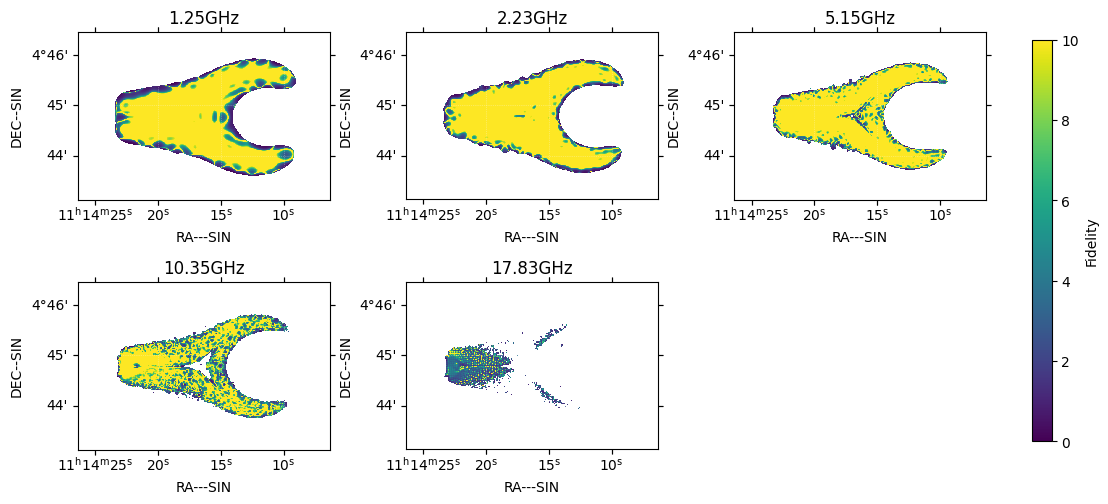

In [22]:
## Fidelity-map panels for Hybrid 120 across the five flare frequencies
from importlib import reload
reload(fss)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.time import Time
import sunpy.map
fidelity_map_cfg = base_cfg
fidelity_map_weighting = 'superuniform'
fidelity_map_deconvolver = 'multiscale'
fidelity_map_crop_fraction = globals().get('plot_crop_fraction', (0.0, 1.0))
fidelity_map_figsize = (11, 5)
fidelity_map_vmin = 0.0
fidelity_map_vmax = 10.0

figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
fidelity_map_figname = os.path.join(figdir, 'fig_h120_fidelity_map.png')

fig = plt.figure(figsize=fidelity_map_figsize, constrained_layout=True)
norm_fid = Normalize(vmin=fidelity_map_vmin, vmax=fidelity_map_vmax)
im_fid = None

for idx, freqstr_local in enumerate(freq_list):
        imsize_local = imsizes[idx]
        cell_local = cells[idx]
        model_fits_local = f'{model_dir}/sep10_flare_cs_model.{freqstr_local}.I.fits'
        model_base_local = os.path.join(project, 'msfiles', target, os.path.basename(model_fits_local.replace('.fits', '.im')))
        model_path_local = fss.resolve_casa_image_path(model_base_local)
        if model_path_local is None or not os.path.exists(model_path_local):
            raise FileNotFoundError(f'Model image not found: {model_base_local}')

        msname_local = fss.make_msname(project, target, freqstr_local, Time(reftime).datetime, duration, integration_time, fidelity_map_cfg, tsys)
        image_path_local = f'{msname_local}_{fidelity_map_weighting}_{fidelity_map_deconvolver}.image'
        if not os.path.exists(image_path_local):
            raise FileNotFoundError(f'Cleaned image not found: {image_path_local}')

        noise_terms_local = fss.calc_noise_terms_for_cfg(
            fidelity_map_cfg,
            model_fits_local,
            freqstr_local,
            imsize_local,
            cell_local,
            tsys,
            duration,
            integration_time,
            channel_width_mhz,
        )

        prep = fss.plot_two_casa_images_with_convolution_sunpy(
            image_path_local,
            model_path_local,
            crop_fraction=fidelity_map_crop_fraction,
            reftime=reftime,
            image_meta={
                'freq': freqstr_local,
                'array_config': fss.simple_array_config_label(fidelity_map_cfg),
                'tsys': f'{tsys:.0f}K',
                'tant': f"{noise_terms_local['tant']:.0f}K",
                'sigma_jy': f"{noise_terms_local['sigma_jy']:.1f}Jy/beam",
                'duration': f'{duration}s',
                'bandwidth': f'{channel_width_mhz}MHz',
                'imaging_weighting': fidelity_map_weighting,
            },
            cmap='hinodexrt',
            vmin=0.1,
            vmax=vmax,
            conv_tag=f'.fidelity_map_{freqstr_local}',
            overwrite_conv=False,
            rms_mask_radius=1.2,
            image_rms_corner_size=image_rms_corner_size,
            coord_frame='radec',
            match_fov=True,
            align_model_time_to_image=True,
            north_up=False,
            apply_hpc_p_angle=False,
            anchor_model_wcs_to_image=True,
            use_reftime_for_hpc=True,
            image_arcsec_shift=image_arcsec_shift,
            return_prepared=True,
        )

        model_mk = np.asarray(prep['data2'], dtype=float) / 1e6
        image_mk = np.asarray(prep['data1'], dtype=float) / 1e6
        resid_mk = np.abs(image_mk - model_mk)
        sigma_t_mk = prep['sigma_tb'] / 1e6 if np.isfinite(prep['sigma_tb']) else np.nan
        source_floor = max(5.0 * sigma_t_mk, 1e-3 * np.nanmax(model_mk)) if np.isfinite(sigma_t_mk) and sigma_t_mk > 0 else 1e-3 * np.nanmax(model_mk)
        denom_floor = sigma_t_mk if np.isfinite(sigma_t_mk) and sigma_t_mk > 0 else np.nanmax(model_mk) * 1e-6
        fidelity_map = model_mk / np.maximum(resid_mk, denom_floor)
        fidelity_map = np.where(model_mk >= source_floor, fidelity_map, np.nan)
        fidelity_map = np.clip(fidelity_map, fidelity_map_vmin, fidelity_map_vmax)

        fidelity_smap = sunpy.map.Map(fidelity_map, prep['sub1'].meta)
        ax = fig.add_subplot(2, 3, idx + 1, projection=fidelity_smap)
        im_fid = fidelity_smap.plot(axes=ax, cmap='viridis', norm=norm_fid)
        ax.set_title(freqstr_local[1:] if freqstr_local.startswith('0') else freqstr_local)
        ax.coords[0].set_axislabel('RA---SIN')
        ax.coords[1].set_axislabel('DEC--SIN')
        ax.grid(color='white', linestyle=':', linewidth=0.5, alpha=0.5)

for idx in range(len(freq_list), 6):
    ax = fig.add_subplot(2, 3, idx + 1)
    ax.axis('off')

cbar = fig.colorbar(im_fid, ax=fig.axes, shrink=0.92)
cbar.set_label('Fidelity')

if os.path.exists(fidelity_map_figname) and overwrite_plot:
    os.system('rm -rf ' + fidelity_map_figname)
fig.savefig(fidelity_map_figname, dpi=200)
print('Saved figure:', fidelity_map_figname)
plt.show()


In [23]:
## Rsync the fidelity-map figure to the memo tex figs folder
fidelity_map_sync_source = fidelity_map_figname if os.path.exists(fidelity_map_figname) else os.path.join(project, figsubfolder, 'fig_hybrid120_fidelity_map_multifreq.png')
rsync_figs_to_memo(renamed={fidelity_map_sync_source: 'fig_h120_fidelity_map.png'})


Running: rsync -av FASR/figs/fig_h120_fidelity_map.png /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/fig_h120_fidelity_map.png
sending incremental file list
fig_h120_fidelity_map.png

sent 291,346 bytes  received 35 bytes  582,762.00 bytes/sec
total size is 291,160  speedup is 1.00
Synced 1 figure(s) to /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs


## Plotting 1D profiles at three slits

In [10]:
# ## Slit-profile comparison: image vs convolved model (one figure per frequency)
# from importlib import reload
# reload(fss)
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from matplotlib.colors import LogNorm
# from astropy.time import Time
# import astropy.units as u

# cfg_for_slit_profile = globals().get('base_cfg', config_files[0])
# cfg_for_slit_profile_2 = globals().get('remote_cfg', config_files[1] if len(config_files) > 1 else cfg_for_slit_profile)
# # show_second_cfg_profile = globals().get('show_second_cfg_profile', False)
# show_second_cfg_profile = False
# cfg_slug_for_slit_profile = fss.simple_array_config_label(cfg_for_slit_profile).lower().replace(' + ', '_plus_').replace(' ', '_')
# cfg_slug_for_slit_profile_2 = fss.simple_array_config_label(cfg_for_slit_profile_2).lower().replace(' + ', '_plus_').replace(' ', '_')
# weighting_for_slit_profile = globals().get('weightings', ['superuniform'])[0]
# deconvolver_for_slit_profile = globals().get('deconvolver', 'multiscale')
# slit_x_fracs = [0.23, 0.49, 0.75]
# slit_half_width_px = 1
# profile_lw = 0.8
# profile_figdir = os.path.join(project, figsubfolder)
# os.makedirs(profile_figdir, exist_ok=True)

# for freqstr, imsize_this, cell_this in zip(freq_list, imsizes, cells):
#     msname = fss.make_msname(
#         project, target, freqstr, Time(reftime).datetime,
#         duration, integration_time, cfg_for_slit_profile, tsys
#     )
#     image_path = f'{msname}_{weighting_for_slit_profile}_{deconvolver_for_slit_profile}.image'

#     msname2 = fss.make_msname(
#         project, target, freqstr, Time(reftime).datetime,
#         duration, integration_time, cfg_for_slit_profile_2, tsys
#     )
#     image_path2 = f'{msname2}_{weighting_for_slit_profile}_{deconvolver_for_slit_profile}.image'

#     model_fits_this = f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits'
#     model_base_this = os.path.join(project, 'msfiles', target, os.path.basename(model_fits_this.replace('.fits', '.im')))
#     model_path = fss.resolve_casa_image_path(model_base_this)

#     if not os.path.exists(image_path):
#         print(f'Skipping missing image: {image_path}')
#         continue
#     if show_second_cfg_profile and not os.path.exists(image_path2):
#         print(f'Skipping missing image: {image_path2}')
#         continue
#     if model_path is None or not os.path.exists(model_path):
#         print(f'Skipping missing model: {model_base_this}')
#         continue

#     prep = fss.plot_two_casa_images_with_convolution_sunpy(
#         image_path,
#         model_path,
#         crop_fraction=globals().get('plot_crop_fraction', (0.0, 1.0)),
#         reftime=reftime,
#         image_meta={'freq': freqstr, 'array_config': fss.simple_array_config_label(cfg_for_slit_profile)},
#         cmap='hinodexrt',
#         vmax=vmax,
#         vmin=0.05,
#         coord_frame='radec',
#         match_fov=True,
#         align_model_time_to_image=True,
#         north_up=False,
#         apply_hpc_p_angle=False,
#         anchor_model_wcs_to_image=True,
#         use_reftime_for_hpc=True,
#         return_prepared=True,
#     )

#     prep2 = None
#     if show_second_cfg_profile:
#         prep2 = fss.plot_two_casa_images_with_convolution_sunpy(
#             image_path2,
#             model_path,
#             crop_fraction=globals().get('plot_crop_fraction', (0.0, 1.0)),
#             reftime=reftime,
#             image_meta={'freq': freqstr, 'array_config': fss.simple_array_config_label(cfg_for_slit_profile_2)},
#             cmap='hinodexrt',
#             vmax=vmax,
#             vmin=0.05,
#             coord_frame='radec',
#             match_fov=True,
#             align_model_time_to_image=True,
#             north_up=False,
#             apply_hpc_p_angle=False,
#             anchor_model_wcs_to_image=True,
#             use_reftime_for_hpc=True,
#             return_prepared=True,
#         )

#     data_img = np.asarray(prep['data1'], dtype=float)
#     data_model = np.asarray(prep['data2'], dtype=float)
#     ny, nx = data_img.shape
#     pixscale_y_arcsec = abs(prep['sub1'].scale.axis2.to_value(u.arcsec / u.pix))
#     y_arcsec = (np.arange(ny) - 0.5 * (ny - 1)) * pixscale_y_arcsec

#     if show_second_cfg_profile:
#         data_img2 = np.asarray(prep2['data1'], dtype=float)
#         ny2, nx2 = data_img2.shape
#         pixscale_y_arcsec2 = abs(prep2['sub1'].scale.axis2.to_value(u.arcsec / u.pix))
#         y_arcsec2 = (np.arange(ny2) - 0.5 * (ny2 - 1)) * pixscale_y_arcsec2
#         fig, (ax_map, ax_prof, ax_prof2) = plt.subplots(1, 3, figsize=(13.5, 4.2), gridspec_kw={'width_ratios': [1.00, 0.5, 0.5]})
#     else:
#         fig, (ax_map, ax_prof) = plt.subplots(1, 2, figsize=(10.0, 4.2), gridspec_kw={'width_ratios': [1.00, 0.5]})

#     map_vmin = float(prep['norm_vmin'])
#     map_vmax = float(prep['norm_vmax'])
#     map_cmap = plt.get_cmap('hinodexrt').copy()
#     map_cmap.set_under(map_cmap(0.0))
#     map_cmap.set_bad(map_cmap(0.0))
#     im = ax_map.imshow(np.ma.masked_invalid(data_model), origin='lower', cmap=map_cmap, aspect='auto',
#                        norm=LogNorm(vmin=map_vmin, vmax=map_vmax))
#     slit_colors = ['deepskyblue', 'lime', 'magenta']

#     for i, (xf, color) in enumerate(zip(slit_x_fracs, slit_colors), start=1):
#         xpix = int(round(xf * (nx - 1)))
#         x0 = max(0, xpix - slit_half_width_px)
#         x1 = min(nx, xpix + slit_half_width_px + 1)
#         prof_img = np.nanmean(data_img[:, x0:x1], axis=1)
#         prof_model = np.nanmean(data_model[:, x0:x1], axis=1)
#         ax_map.axvline(xpix, color=color, lw=1.0)
#         ax_prof.plot(prof_img, y_arcsec, color=color, lw=profile_lw, linestyle='-')
#         ax_prof.plot(prof_model, y_arcsec, color=color, lw=profile_lw, linestyle=':')

#     if show_second_cfg_profile:
#         for i, (xf, color) in enumerate(zip(slit_x_fracs, slit_colors), start=1):
#             xpix2 = int(round(xf * (nx2 - 1)))
#             x0_2 = max(0, xpix2 - slit_half_width_px)
#             x1_2 = min(nx2, xpix2 + slit_half_width_px + 1)
#             prof_img2 = np.nanmean(data_img2[:, x0_2:x1_2], axis=1)
#             prof_model2 = np.nanmean(np.asarray(prep2['data2'], dtype=float)[:, x0_2:x1_2], axis=1)
#             ax_prof2.plot(prof_img2, y_arcsec2, color=color, lw=profile_lw, linestyle='-')
#             ax_prof2.plot(prof_model2, y_arcsec2, color=color, lw=profile_lw, linestyle=':')

#     ax_map.set_title(f'{freqstr.lstrip("0")} model (convolved)')
#     ax_map.set_xlabel('X pixel')
#     ax_map.set_ylabel('Y pixel')
#     ax_map.set_aspect('equal')
#     fig.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04, label=r'T$_B$ [K]')

#     ax_prof.set_title(f'slit profiles ({fss.simple_array_config_label(cfg_for_slit_profile)})')
#     ax_prof.set_xlabel(r'T$_B$ [K]')
#     ax_prof.set_ylabel('Relative Y [arcsec]')
#     ax_prof.set_xscale('log')
#     ax_prof.grid(True, alpha=0.3, linestyle=':')
#     legend_handles = [
#         Line2D([0], [0], color='black', lw=profile_lw, linestyle='-', label='Image'),
#         Line2D([0], [0], color='black', lw=profile_lw, linestyle=':', label='Model'),
#     ]
#     ax_prof.legend(handles=legend_handles, fontsize=8, ncol=1, loc='upper right')
#     xlim_prof = ax_prof.get_xlim()
#     ax_prof.set_xlim(0.0001 * xlim_prof[1], xlim_prof[1])

#     if show_second_cfg_profile:
#         ax_prof2.set_title(f'slit profiles ({fss.simple_array_config_label(cfg_for_slit_profile_2)})'.replace('Hybrid 120 ', ''))
#         ax_prof2.set_xlabel(r'T$_B$ [K]')
#         ax_prof2.set_ylabel('Relative Y [arcsec]')
#         ax_prof2.set_xscale('log')
#         ax_prof2.grid(True, alpha=0.3, linestyle=':')
#         ax_prof2.legend(handles=legend_handles, fontsize=8, ncol=1, loc='upper right')
#         xlim_prof2 = ax_prof2.get_xlim()
#         ax_prof2.set_xlim(0.0001 * xlim_prof2[1], xlim_prof2[1])

#     if show_second_cfg_profile:
#         fig.suptitle(f'{freqstr.lstrip("0")}: slit-profile comparison', y=1.0)
#     plt.tight_layout()
#     if show_second_cfg_profile:
#         profile_figname = os.path.join(
#             profile_figdir,
#             f'fig_slit_profiles_compare_{cfg_slug_for_slit_profile}_vs_{cfg_slug_for_slit_profile_2}_{freqstr}_{weighting_for_slit_profile}_{deconvolver_for_slit_profile}.png'
#         )
#     else:
#         profile_figname = os.path.join(
#             profile_figdir,
#             f'fig_slit_profiles_{cfg_slug_for_slit_profile}_{freqstr}_{weighting_for_slit_profile}_{deconvolver_for_slit_profile}.png'
#         )
#     fig.savefig(profile_figname, dpi=200, bbox_inches='tight')
#     print(f'Saved {profile_figname}')
#     plt.show()



In [11]:
# ## Rsync the slit-profile figures to the memo tex figs folder
# rsync_figs_to_memo(
#     patterns=[
#         'fig_slit_profiles_hybrid_120_*_superuniform_multiscale.png',
#         'fig_slit_profiles_compare_hybrid_120_vs_hybrid_120_plus_10_remote_*_superuniform_multiscale.png',
#     ]
# )


In [12]:
pwd

'/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul'

In [13]:
im_path,msfile,imname

('FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image',
 'FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K.ms',
 'FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale')

## Super-Resolution / Long-Baseline Emphasis Options
With only a small number of remote antennas, the very long baselines are sparse. Even `uniform` weighting may not emphasize them enough. Below are two practical approaches that can push resolution beyond what uniform weighting gives.

1) **UV-range split + combine**: image long baselines only (high-res) and short baselines only (low-res), then combine in the image domain (e.g., `feather`).
2) **Manual weight boost**: multiply the MS `WEIGHT` / `SIGMA` by a function of UV-distance to upweight long baselines more strongly than uniform weighting.

Notes:
- Both methods increase noise in the final image and can create ringing if the long-baseline PSF sidelobes are high.
- Multi-scale deconvolution and tighter clean masks help stability.


In [81]:
## Super-resolution products and diagnostics (cfg-driven, one cfg per call)
from importlib import reload
reload(fss)
import os
import numpy as np

freqstr = '05.15GHz'
vmax = 100
crop_fraction = globals().get('plot_crop_fraction', (0.0, 1.0))
image_rms_corner_size = 20
# uvthr_klambda_list = [3.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0]
uvthr_klambda_list = [5.0, 10.0, 20.0, 30.0]
boost_param_grid = [(10, 1.5), (10, 2.0), (20, 1.5), (20, 2.0), (30, 1.5), (30, 2.0)]
max_boost = 3.0
uv_density_bin_m = 10.0
superres_weighting_default = 'superuniform'
use_boost_restoringbeam = True
apply_default_calibration = globals().get('apply_default_calibration', True)
show_cal_error_text = globals().get('show_cal_error_text', False)

if freqstr not in freq_list:
    raise ValueError(f'freqstr {freqstr} is not in freq_list={freq_list}')
freq_idx = freq_list.index(freqstr)
imsize = imsizes[freq_idx]
cell = cells[freq_idx]
scales_default = scales[freq_idx]

cal_errors = globals().get('cal_errors', [(0.1, 0.1)])
phaerr, amperr = cal_errors[0]
phasecenter_tclean = globals().get('phasecenter_tclean', 'J2000 11h14m13.36s +30d04m44s')

model_fits = globals().get('superres_model_fits', f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits')
model_base = os.path.join(project, 'msfiles', target, os.path.basename(model_fits.replace('.fits', '.im')))
model_path = fss.resolve_casa_image_path(model_base)
if model_path is None or not os.path.exists(model_path):
    raise FileNotFoundError(f'Model image not found: {model_base}')

figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
caltbdir = os.path.join(project, 'caltbs')
os.makedirs(caltbdir, exist_ok=True)

image_meta_common = {
    'freq': freqstr,
    'tsys': f'{tsys:.0f}K' if 'tsys' in globals() else None,
    'cal_error': f'{np.rad2deg(phaerr):.0f}' + r'$^{\circ}$ Pha' + f' & {np.int_(amperr * 100)}% Amp',
    'duration': f'{duration}s' if 'duration' in globals() else None,
    'bandwidth': f'{channel_width_mhz}MHz' if 'channel_width_mhz' in globals() else None,
}

_noise_terms_cache = {}

def run_superres_products(cfg_file, cfg_label=None, superres_option=None, deconvolver_override=None, weighting='superuniform'):
    """Run super-resolution products for one array cfg."""
    cfg_label_text = cfg_label if cfg_label is not None else fss.humanize_array_config_label(cfg_file)
    scales_use = scales_by_cfg.get(freqstr, {}).get(os.path.basename(cfg_file), scales_default)
    msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, cfg_file, tsys)
    msfile = msname + '.ms'

    if cfg_file not in _noise_terms_cache:
        _noise_terms_cache[cfg_file] = fss.calc_noise_terms_for_cfg(
            cfg_file,
            model_fits,
            freqstr,
            imsize,
            cell,
            tsys,
            duration,
            integration_time,
            channel_width_mhz,
        )
    noise_terms = _noise_terms_cache[cfg_file]

    overwrite_ms_local = bool(globals().get('overwrite_ms', False))
    if os.path.exists(msfile) and overwrite_ms_local:
        fss.remove_path(msfile)
    if not os.path.exists(msfile):
        print('Start generating ms:', msfile)
        reftime_casa_local = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')
        msfile = fss.generate_ms(
            cfg_file,
            model_fits,
            reftime_casa_local,
            freqstr,
            integration_time=integration_time,
            duration=duration,
            channel_width_mhz=channel_width_mhz,
            msname=msfile,
            tsys=tsys,
            usehourangle=True,
            uv_cell=noise_terms['uv_cell'],
        )

    if apply_default_calibration:
        calibrated_msfile = fss.ensure_default_calibration(
            msfile,
            phaerr,
            amperr,
            caltbdir=caltbdir,
            overwrite=overwrite_ms_local,
        )
    else:
        calibrated_msfile = msfile

    overwrite_images = bool(globals().get('overwrite_superres_im', False) or globals().get('overwrite_im', False))
    overwrite_boost_ms = bool(globals().get('overwrite_boost_ms', False))
    deconv_use = deconvolver if deconvolver_override is None else deconvolver_override
    weighting_use = str(weighting).strip().lower() if weighting is not None else superres_weighting_default
    if not weighting_use:
        weighting_use = superres_weighting_default

    valid_options = {'feather', 'boost'}
    if superres_option is None:
        selected = set(valid_options)
        selected_mode = False
    else:
        if isinstance(superres_option, str):
            selected = {s.strip().lower() for s in superres_option.split(',') if s.strip()}
        elif isinstance(superres_option, (list, tuple, set)):
            selected = {str(s).strip().lower() for s in superres_option if str(s).strip()}
        else:
            raise TypeError('superres_option must be None, str, list, tuple, or set')
        invalid = selected - valid_options
        if invalid:
            raise ValueError(f'Invalid superres_option value(s): {sorted(invalid)}; allowed: {sorted(valid_options)}')
        selected_mode = True

    def plot_product(image_path, title_left, conv_tag, suffix, extra_meta=None):
        meta = dict(image_meta_common)
        meta['title_left'] = title_left
        fss.plot_compare_casa_vs_model(
            image_path=image_path,
            model_path=model_path,
            cfg_label_text=cfg_label_text,
            noise_terms=noise_terms,
            image_meta_common=meta,
            reftime=reftime,
            crop_fraction=crop_fraction,
            figsize=(10, 3.6),
            cmap='hinodexrt',
            vmax=vmax,
            conv_tag=conv_tag,
            image_rms_corner_size=image_rms_corner_size,
            suffix=suffix,
            figdir=figdir,
            overwrite_plot=overwrite_plot,
            extra_meta=extra_meta,
            show_cal_error_text=show_cal_error_text,
        )

    if 'feather' in selected:
        split_products = {}
        for thr in uvthr_klambda_list:
            split_products[thr] = fss.ensure_split_feather(
                msfile=calibrated_msfile,
                msname=msname,
                uvthr_klambda=thr,
                cell=cell,
                deconvolver=deconv_use,
                scales=scales_use,
                imsize=imsize,
                phasecenter=phasecenter_tclean,
                niter=niter,
                overwrite_images=overwrite_images,
                weighting=weighting_use,
            )
            plot_product(split_products[thr]['short'], f'Cleaned image (uv<{thr}k, {cfg_label_text})', f'.short_uvlt{thr}k', f'short_uvlt{thr}k', {'imaging_weighting': weighting_use, 'uvrange': f'uv<{thr}k'})
            plot_product(split_products[thr]['long'], f'Cleaned image (uv>{thr}k, {cfg_label_text})', f'.long_uvgt{thr}k', f'long_uvgt{thr}k', {'imaging_weighting': weighting_use, 'uvrange': f'uv>{thr}k'})
            plot_product(split_products[thr]['feather'], f'Cleaned image (feathered, uvthr={thr}k, {cfg_label_text})', f'.feather_uvthr{thr}k', f'feather_uvthr{thr}k', {'imaging_weighting': f'feather ({weighting_use})'})

        fss.plot_uv_density_splits(msfile, cfg_label_text, uvthr_klambda_list, figdir, freqstr, bin_m=uv_density_bin_m)

    if 'boost' in selected:
        uvrange_min_kl = min(uvthr_klambda_list)
        for uv0, pwr in boost_param_grid:
            boost_path = fss.ensure_boost_image(
                msfile=calibrated_msfile,
                msname=msname,
                freqstr=freqstr,
                uv0_klambda=uv0,
                power=pwr,
                max_boost=max_boost,
                cell=cell,
                deconvolver=deconv_use,
                scales=scales_use,
                imsize=imsize,
                phasecenter=phasecenter_tclean,
                niter=niter,
                overwrite_ms=overwrite_boost_ms,
                overwrite_image=overwrite_images,
                uvrange_min_klambda=uvrange_min_kl,
                use_boost_restoringbeam=use_boost_restoringbeam,
                weighting=weighting_use,
            )
            plot_product(boost_path, f'Cleaned image (boosted uv0={uv0}k, p={pwr}, {cfg_label_text})', f'.boost_uv0{uv0}k_p{pwr}', f'boost_uv0{uv0}k_p{pwr}_max{max_boost}', {'imaging_weighting': f'boosted ({weighting_use})'})

        fss.plot_boost_weighting_curves(msfile, cfg_label_text, boost_param_grid, figdir, freqstr, max_boost, uvrange_min_klambda=uvrange_min_kl)


Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
1660.84
Calculate antenna temperature from total flux 1660.84 sfu incident on the dish
Total noise temperature (K): 6.677e+03 K
Estimated SEFD: 1.869e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.257e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.823e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.698e+03 Jy for 7140 baselines


2026-03-07 18:26:09	WARN	clearcal::calibrater::setvi(bool,bool)	Forcing use of OLD VisibilityIterator.


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p1.5_image_superuniform_multiscale.image: 2.672e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p1.5_image_superuniform_multiscale.image (off-disk/border): 8.544e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.648e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (of

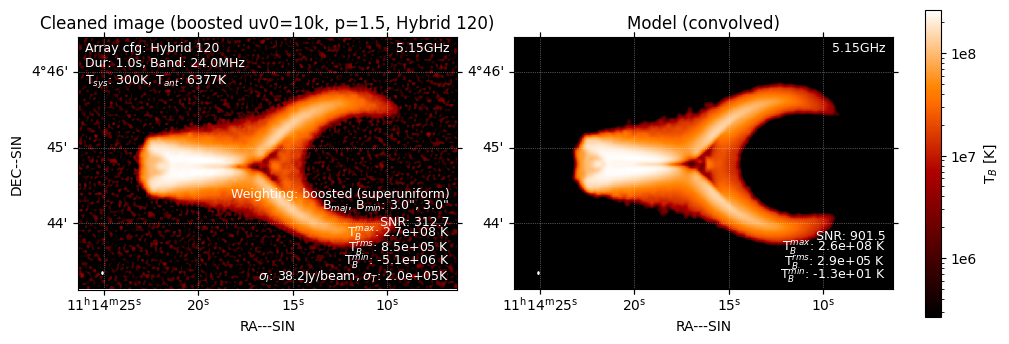

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p1.5_image_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv010k_p1.5_max3.0_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p2.0_image_superuniform_multiscale.image: 2.679e+08 K
rms of fasr_fasr-a_random_spiral_hy

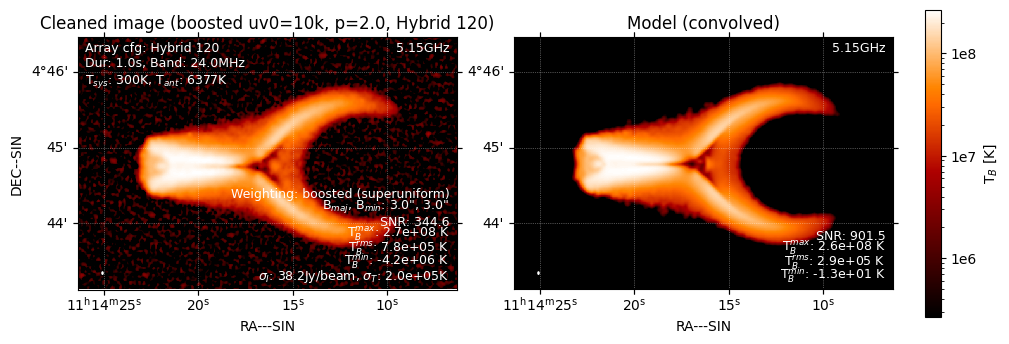

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p2.0_image_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv010k_p2.0_max3.0_cropx15-90_y25-75.jpg


2026-03-07 18:26:16	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.5 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv020k_p1.5_image_superuniform_multiscale.image: 2.968e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv020k_p1.5_image_superuniform_multiscale.image (off-disk/border): 2.431e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (of

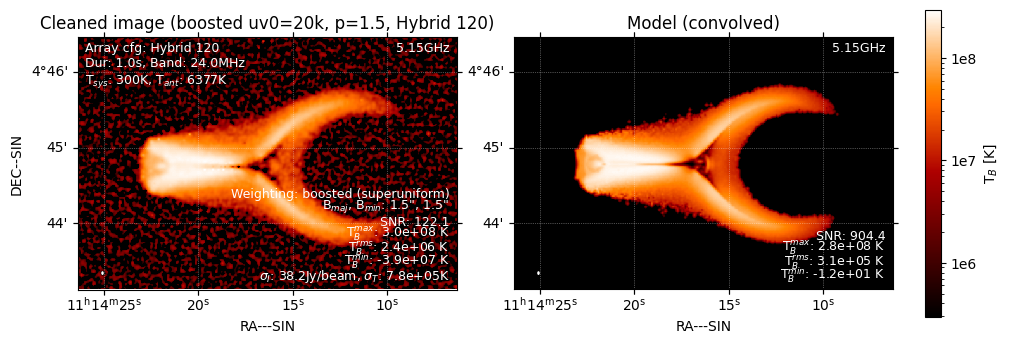

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv020k_p1.5_image_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv020k_p1.5_max3.0_cropx15-90_y25-75.jpg


2026-03-07 18:26:18	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.5 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv020k_p2.0_image_superuniform_multiscale.image: 2.976e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv020k_p2.0_image_superuniform_multiscale.image (off-disk/border): 3.636e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (of

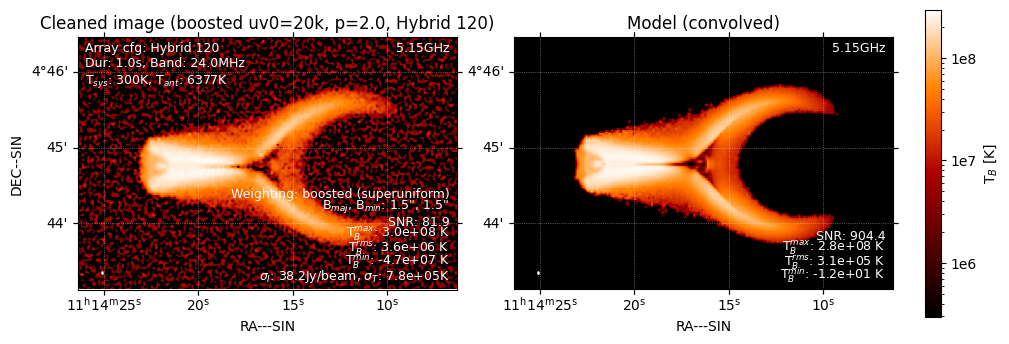

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv020k_p2.0_image_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv020k_p2.0_max3.0_cropx15-90_y25-75.jpg


2026-03-07 18:26:20	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv030k_p1.5_image_superuniform_multiscale.image: 3.808e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv030k_p1.5_image_superuniform_multiscale.image (off-disk/border): 5.335e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.754e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (of

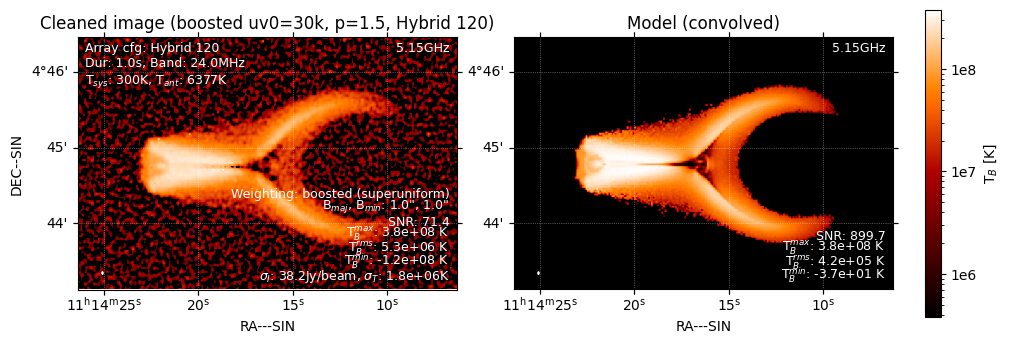

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv030k_p1.5_image_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv030k_p1.5_max3.0_cropx15-90_y25-75.jpg


2026-03-07 18:26:24	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv030k_p2.0_image_superuniform_multiscale.image: 3.646e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv030k_p2.0_image_superuniform_multiscale.image (off-disk/border): 6.573e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.754e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (of

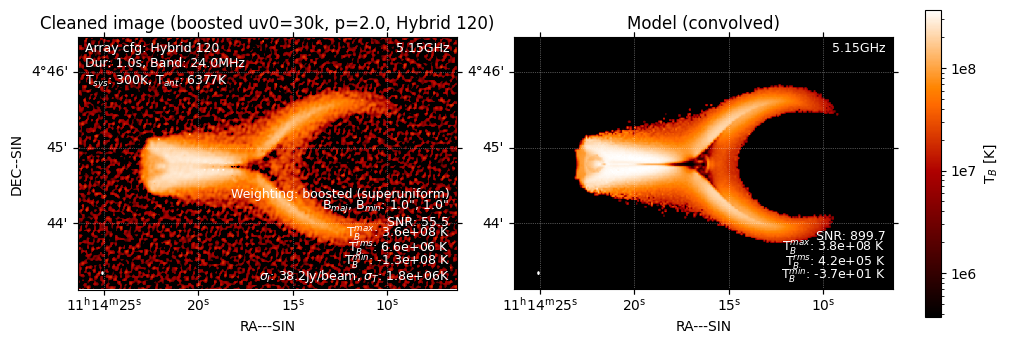

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv030k_p2.0_image_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv030k_p2.0_max3.0_cropx15-90_y25-75.jpg
Saved figure: FASR/figs/fig-boost_weighting_curves_fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K.jpg


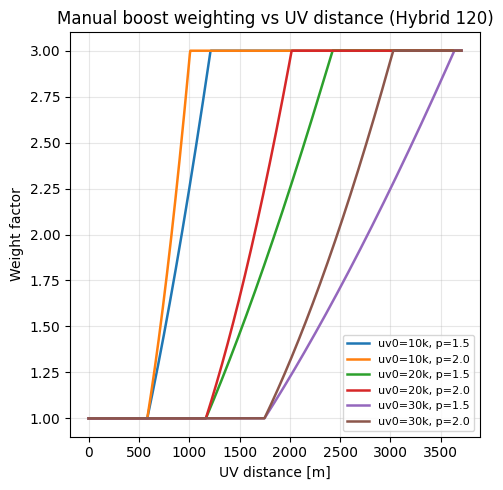

In [82]:
run_superres_products(base_cfg, superres_option='boost', deconvolver_override='multiscale', weighting='superuniform')

2026-03-07 18:26:37	WARN	clearcal::calibrater::setvi(bool,bool)	Forcing use of OLD VisibilityIterator.


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt5.0k_0.5arcsec_superuniform_multiscale.image: 1.828e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt5.0k_0.5arcsec_superuniform_multiscale.image (off-disk/border): 2.331e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 1.844e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.006e+05 K
Plotting both

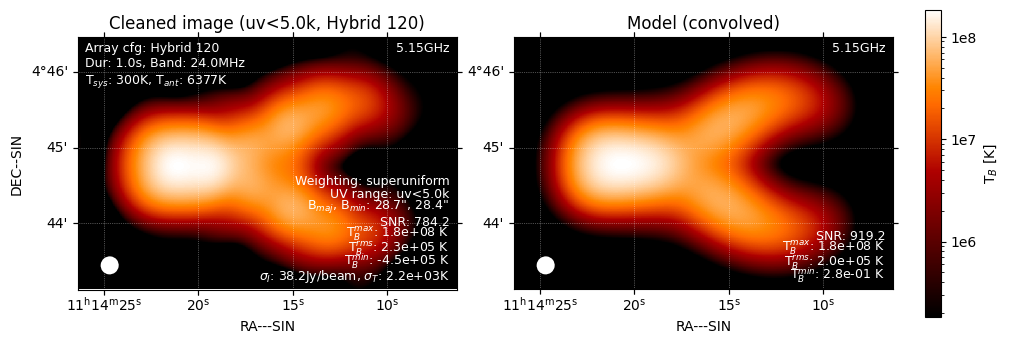

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt5.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt5.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt5.0k_0.5arcsec_superuniform_multiscale.image: 1.094e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_

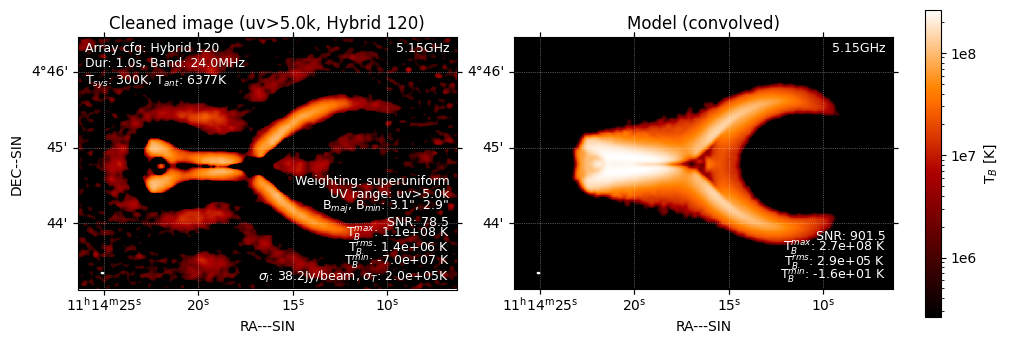

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt5.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt5.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr5.0k_superuniform_multiscale.image: 3.887e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_in

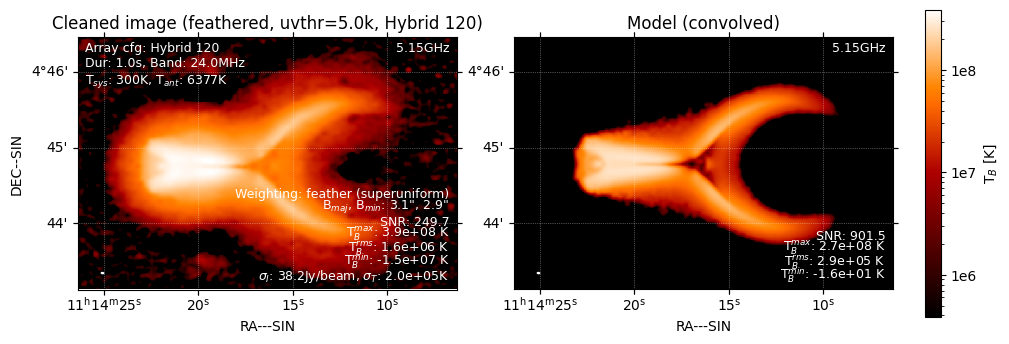

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr5.0k_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr5.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt10.0k_0.5arcsec_superuniform_multiscale.image: 2.465e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur

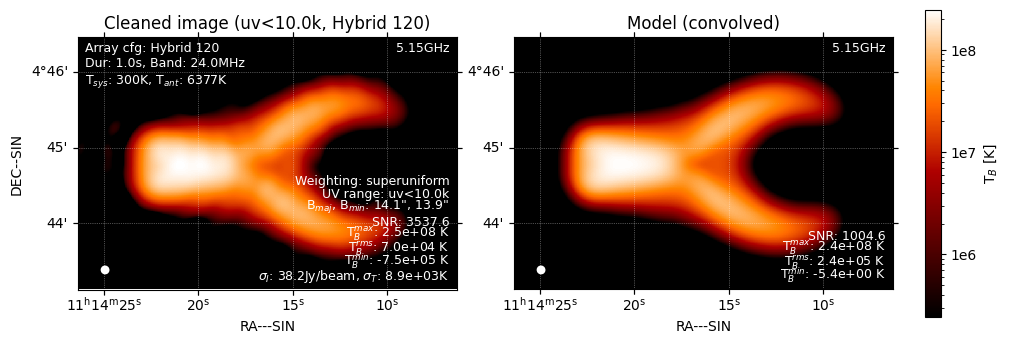

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt10.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt10.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt10.0k_0.5arcsec_superuniform_multiscale.image: 7.213e+07 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur

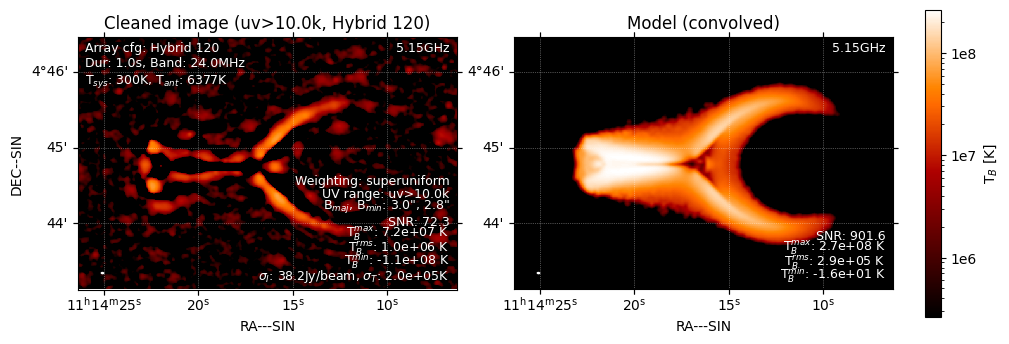

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt10.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt10.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr10.0k_superuniform_multiscale.image: 4.756e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s

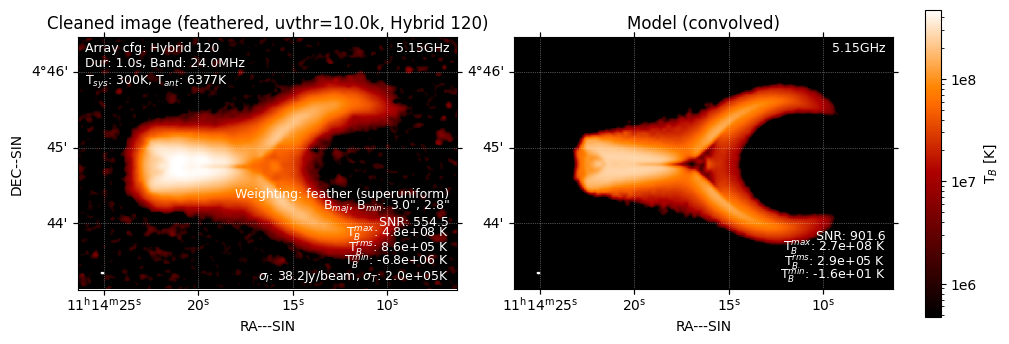

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr10.0k_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr10.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt20.0k_0.5arcsec_superuniform_multiscale.image: 2.497e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_d

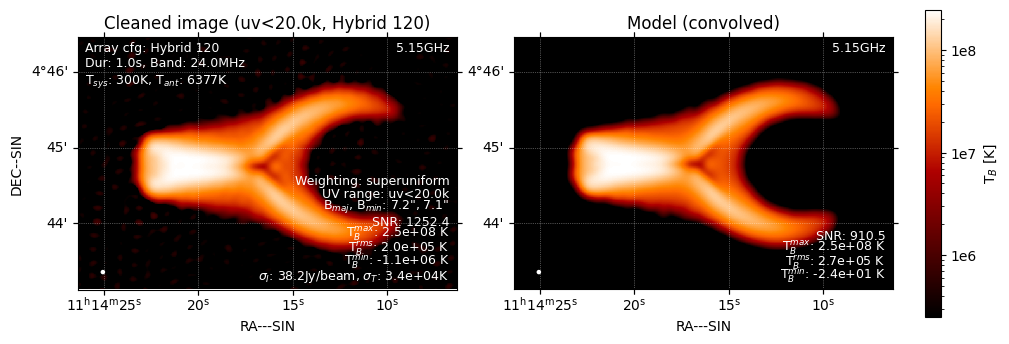

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt20.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt20.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt20.0k_0.5arcsec_superuniform_multiscale.image: 1.234e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur

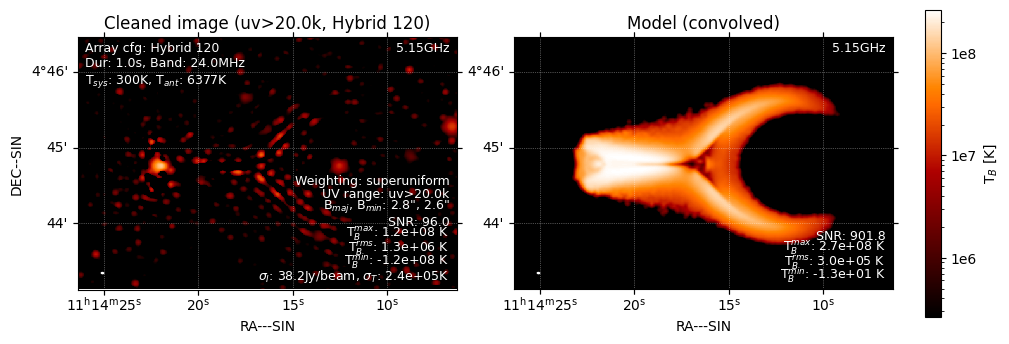

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt20.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt20.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr20.0k_superuniform_multiscale.image: 5.013e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s

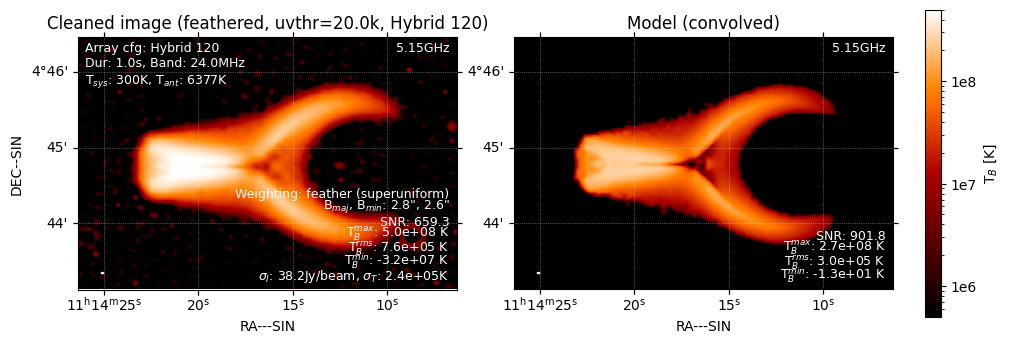

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr20.0k_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr20.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt30.0k_0.5arcsec_superuniform_multiscale.image: 2.758e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_d

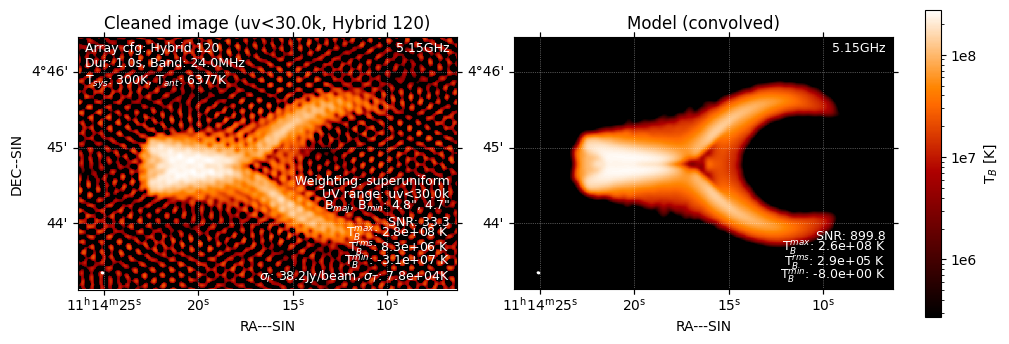

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt30.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt30.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt30.0k_0.5arcsec_superuniform_multiscale.image: 9.478e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur

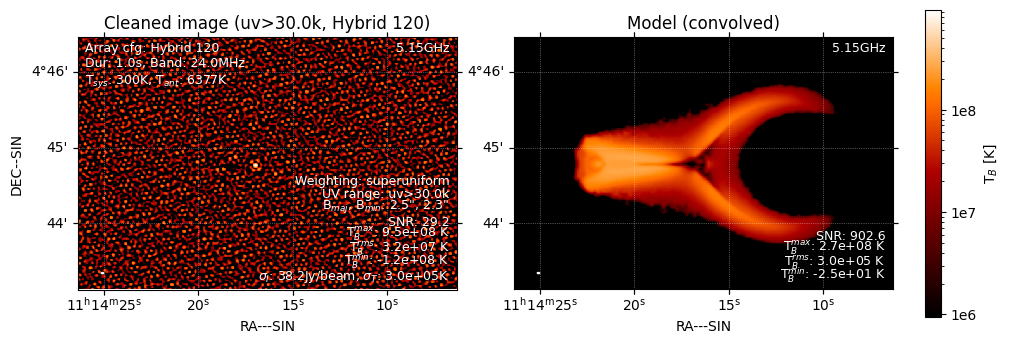

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvgt30.0k_0.5arcsec_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt30.0k_cropx15-90_y25-75.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr30.0k_superuniform_multiscale.image: 8.298e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s

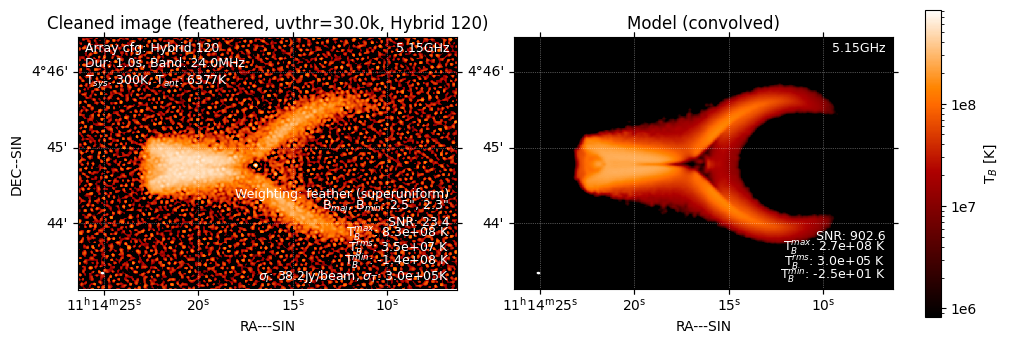

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_feather_uvthr30.0k_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr30.0k_cropx15-90_y25-75.jpg
Saved figure: FASR/figs/fig-uv_density_split_compare_fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K.jpg


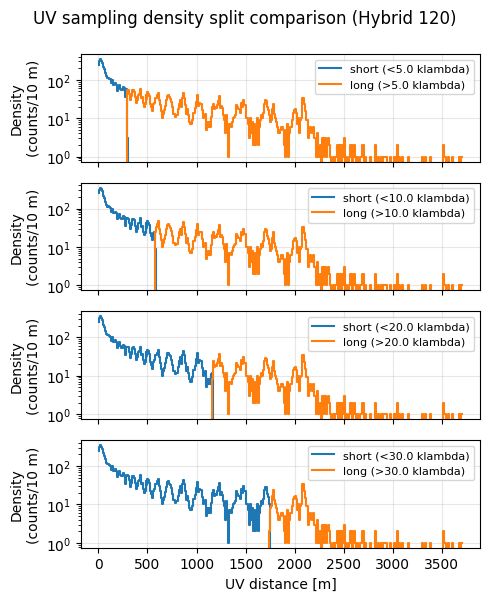

In [83]:
run_superres_products(base_cfg, superres_option='feather', deconvolver_override='multiscale', weighting='superuniform')

In [ ]:
print("Use variable-based paths in flare mode; hardcoded path removed")


Use variable-based paths in flare mode; hardcoded path removed


### make the figures

Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
1660.84
Calculate antenna temperature from total flux 1660.84 sfu incident on the dish
Total noise temperature (K): 6.677e+03 K
Estimated SEFD: 1.869e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.257e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.823e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.698e+03 Jy for 7140 baselines
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radiu

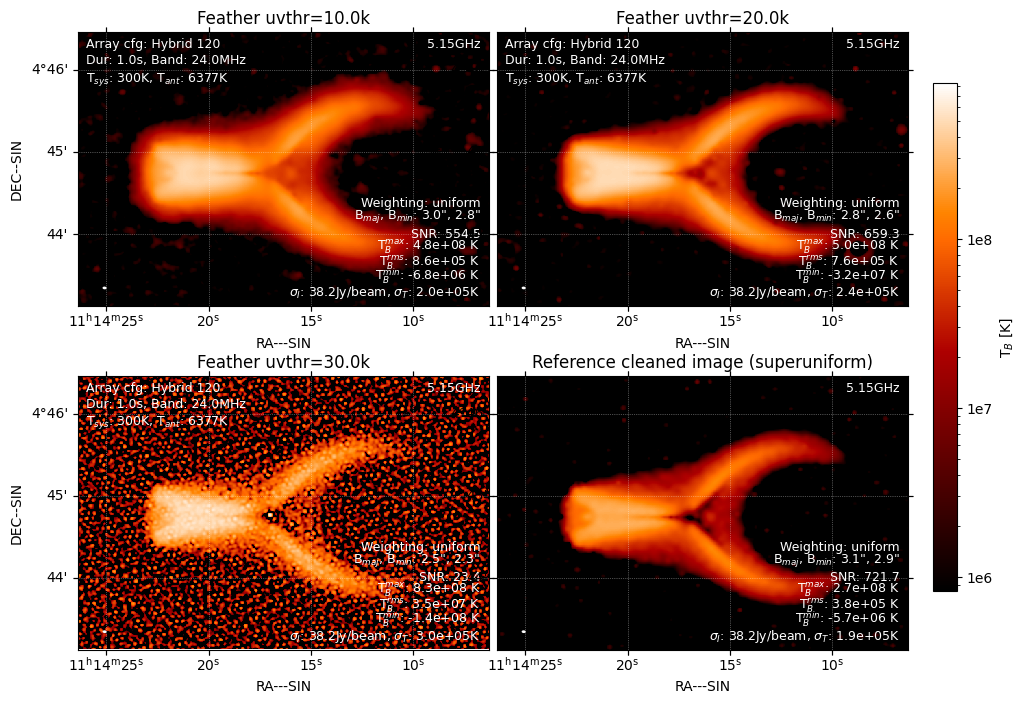

Saved figure: FASR/figs/fig-superres_feather_multiscale_4cases_vs_reference_cleaned.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt10.0k_0.5arcsec_superuniform_multiscale.image: 2.465e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_uvlt10.0k_0.5arcsec_superuniform_multiscale.image (off-disk/border): 6.967e+04 K
Peak of fasr_fasr-a_random_spiral_hybrid_120_

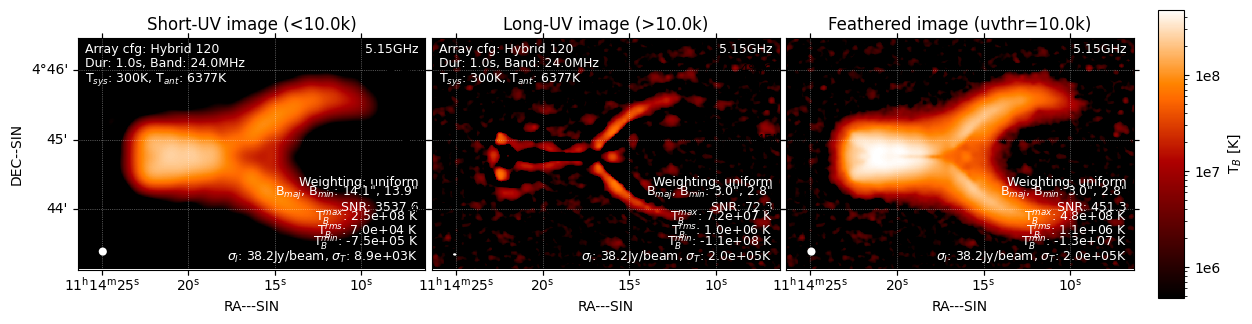

Saved figure: FASR/figs/fig-superres_feather_components_uvthr10k.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p2.0_image_superuniform_multiscale.image: 2.679e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_defaultcal_wboost_uv010k_p2.0_image_superuniform_multiscale.image (off-disk/border): 7.775e+05 K
Peak of fasr_fasr-a_random_spira

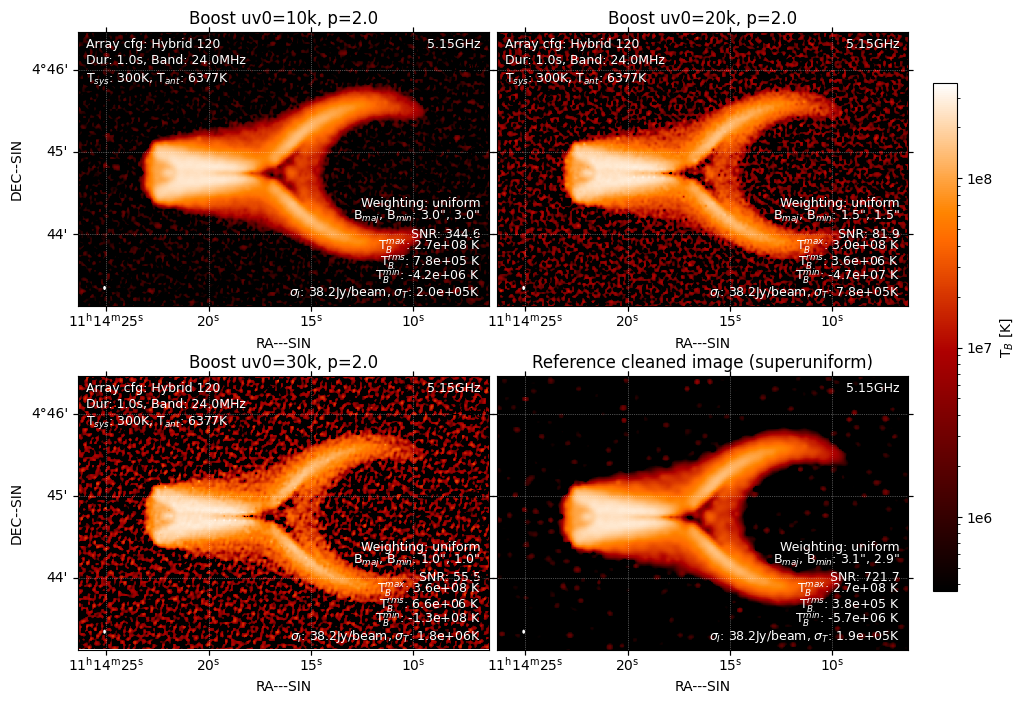

Saved figure: FASR/figs/fig-superres_boost_multiscale_3cases_vs_reference_cleaned.jpg


In [90]:
# Manuscript figure assembly from existing products (no clean / no run_superres_products)
# This cell builds manuscript composites using the original cleaned superuniform image as the reference.

from importlib import reload
reload(fss)
from astropy.time import Time

# ---- User inputs ----
feather_thresholds_kl = [10.0, 20.0, 30.0]
feather_component_threshold_kl = 10.0
boost_params = [(10, 2.0), (20, 2.0), (30, 2.0)]
superres_deconvolver_for_manuscript = 'multiscale'
manuscript_reference_weighting = 'superuniform'
crop_fraction = globals().get('plot_crop_fraction', (0.0, 1.0))

_msname_for_cfg_local = globals().get(
    '_msname_for_cfg',
    lambda cfg_file: fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, cfg_file, tsys),
)
_msfile_for_cfg_local = globals().get(
    '_msfile_for_cfg',
    lambda cfg_file: _msname_for_cfg_local(cfg_file) + '.ms',
)

msname_base = _msname_for_cfg_local(base_cfg)
msfile_base = _msfile_for_cfg_local(base_cfg)
reference_cleaned_image = f'{msname_base}_{manuscript_reference_weighting}_{superres_deconvolver_for_manuscript}.image'
boost_curve_source = os.path.join(figdir, f'fig-boost_weighting_curves_{os.path.basename(msname_base)}.jpg')
if not os.path.exists(reference_cleaned_image):
    raise FileNotFoundError(f'Reference cleaned image not found: {reference_cleaned_image}')

manuscript_noise_terms = fss.calc_noise_terms_for_cfg(
    base_cfg,
    model_fits,
    freqstr,
    imsize,
    cell,
    tsys,
    duration,
    integration_time,
    channel_width_mhz,
)

def _fmt_uv0(uv0):
    u = float(uv0)
    return f'{int(u)}' if abs(u - int(u)) < 1e-9 else str(u)

def _fmt_p(p):
    p = float(p)
    return f'{int(p)}' if abs(p - int(p)) < 1e-9 else str(p)

def _feather_image_path(thr):
    base = f'{msname_base}_feather_uvthr{thr}k_{manuscript_reference_weighting}_{superres_deconvolver_for_manuscript}'
    return base + '.image'

def _split_image_path(thr, branch):
    if branch not in ('short', 'long'):
        raise ValueError(f'branch must be short or long, got {branch}')
    prefix = 'uvlt' if branch == 'short' else 'uvgt'
    base = f'{msname_base}_{prefix}{thr}k_{cell}_{manuscript_reference_weighting}_{superres_deconvolver_for_manuscript}'
    return base + '.image'

def _boost_image_path(uv0, power):
    uv_vals = [str(uv0)]
    p_vals = [str(power)]
    try:
        uvf = float(uv0)
        if uvf.is_integer():
            uv_vals.extend([str(int(uvf)), f'{uvf:.1f}'])
    except Exception:
        pass
    try:
        pf = float(power)
        if pf.is_integer():
            p_vals.extend([str(int(pf)), f'{pf:.1f}'])
    except Exception:
        pass

    uv_vals = list(dict.fromkeys(uv_vals))
    p_vals = list(dict.fromkeys(p_vals))

    ms_bases = [msfile_base]
    if msfile_base.endswith('.ms'):
        ms_bases.append(msfile_base.replace('.ms', '_defaultcal.ms'))
    ms_bases = list(dict.fromkeys(ms_bases))

    candidates = []
    for ms_base in ms_bases:
        for uv_s in uv_vals:
            for p_s in p_vals:
                ms_boost = ms_base.replace('.ms', f'_wboost_uv0{uv_s}k_p{p_s}.ms')
                candidates.append(ms_boost.replace('.ms', '') + f'_image_{manuscript_reference_weighting}_{superres_deconvolver_for_manuscript}.image')

    for cpath in candidates:
        if os.path.exists(cpath):
            return cpath
    return candidates[0]

feather_images = [_feather_image_path(t) for t in feather_thresholds_kl]
boost_images = [_boost_image_path(u, p) for u, p in boost_params]
feather_component_images = [
    _split_image_path(feather_component_threshold_kl, 'short'),
    _split_image_path(feather_component_threshold_kl, 'long'),
]
feather_component_reference = _feather_image_path(feather_component_threshold_kl)

missing_feather = [p for p in feather_images if not os.path.exists(p)]
missing_boost = [p for p in boost_images if not os.path.exists(p)]
missing_components = [p for p in feather_component_images + [feather_component_reference] if not os.path.exists(p)]
if missing_feather:
    raise FileNotFoundError('Missing feather multiscale image(s):\n' + '\n'.join(missing_feather))
if missing_boost:
    raise FileNotFoundError(
        'Missing boost multiscale image(s):\n' + '\n'.join(missing_boost) +
        '\n\nUse existing multiscale boost outputs only, or generate them before running this cell.'
    )
if missing_components:
    raise FileNotFoundError('Missing feather component image(s):\n' + '\n'.join(missing_components))

feather_titles = [f'Feather uvthr={thr}k' for thr in feather_thresholds_kl]
boost_titles = [f'Boost uv0={u}k, p={p}' for u, p in boost_params]
feather_component_titles = [
    f'Short-UV image (<{feather_component_threshold_kl}k)',
    f'Long-UV image (>{feather_component_threshold_kl}k)',
]

fig_feather, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    feather_images,
    reference_cleaned_image,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(10,7.25),
    panel_titles=feather_titles,
    image_meta={
        **image_meta_common,
        'title': ['Feathering parameter sweep', f'Reference cleaned image ({manuscript_reference_weighting})'],
        'array_config': 'Hybrid 120',
        'tant': f"{manuscript_noise_terms['tant']:.0f}K",
        'sigma_jy': f"{manuscript_noise_terms['sigma_jy']:.1f}Jy/beam",
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_reference_cleaned',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_feather = os.path.join(figdir, 'fig_feather_sweep.jpg')
if os.path.exists(figname_feather) and overwrite_plot:
    os.system('rm -rf ' + figname_feather)
if not os.path.exists(figname_feather):
    fig_feather.savefig(figname_feather, dpi=200)
    print('Saved figure:', figname_feather)

fig_feather_components, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    feather_component_images,
    feather_component_reference,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(12, 4),
    panel_titles=feather_component_titles,
    image_meta={
        **image_meta_common,
        'title': ['Feather workflow decomposition', f'Feathered image (uvthr={feather_component_threshold_kl}k)'],
        'array_config': 'Hybrid 120',
        'tant': f"{manuscript_noise_terms['tant']:.0f}K",
        'sigma_jy': f"{manuscript_noise_terms['sigma_jy']:.1f}Jy/beam",
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_feather_reference',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_feather_components = os.path.join(figdir, 'fig_feather_components.jpg')
if os.path.exists(figname_feather_components) and overwrite_plot:
    os.system('rm -rf ' + figname_feather_components)
if not os.path.exists(figname_feather_components):
    fig_feather_components.savefig(figname_feather_components, dpi=200)
    print('Saved figure:', figname_feather_components)

fig_boost, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    boost_images,
    reference_cleaned_image,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(10,7.25),
    panel_titles=boost_titles,
    image_meta={
        **image_meta_common,
        'title': ['Boost parameter sweep', f'Reference cleaned image ({manuscript_reference_weighting})'],
        'array_config': 'Hybrid 120',
        'tant': f"{manuscript_noise_terms['tant']:.0f}K",
        'sigma_jy': f"{manuscript_noise_terms['sigma_jy']:.1f}Jy/beam",
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_reference_cleaned',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_boost = os.path.join(figdir, 'fig_boost_sweep.jpg')
if os.path.exists(figname_boost) and overwrite_plot:
    os.system('rm -rf ' + figname_boost)
if not os.path.exists(figname_boost):
    fig_boost.savefig(figname_boost, dpi=200)
    print('Saved figure:', figname_boost)


In [91]:
## Rsync the super-resolution summary figures to the memo tex figs folder
rsync_figs_to_memo(
    figname_feather,
    figname_feather_components,
    figname_boost,
    renamed={boost_curve_source: 'fig_boost_curves.jpg'},
)


Running: rsync -av FASR/figs/fig-superres_feather_multiscale_4cases_vs_reference_cleaned.jpg FASR/figs/fig-superres_feather_components_uvthr10k.jpg FASR/figs/fig-superres_boost_multiscale_3cases_vs_reference_cleaned.jpg /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs/
sending incremental file list
fig-superres_boost_multiscale_3cases_vs_reference_cleaned.jpg
fig-superres_feather_components_uvthr10k.jpg
fig-superres_feather_multiscale_4cases_vs_reference_cleaned.jpg

sent 1,074,514 bytes  received 73 bytes  2,149,174.00 bytes/sec
total size is 1,073,917  speedup is 1.00
Synced 3 figure(s) to /Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/manuscripts/FASR/FASR_Flare_and_Compact_Source/figs


In [ ]:
## next step: add noise esitmate from quiet sun ipynb